In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
import io
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, \
precision_score, recall_score, f1_score
import joblib
from google.colab import files
import seaborn as sns
!pip install dbfread

In [ ]:
# 한글폰트
# 실행후 런타임 재실행 필수

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,377 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and direc

In [ ]:
# 한글폰트

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path, size=12)

matplotlib.rc('font', family='NanumGothic')

# 마이너스 깨짐 방지
matplotlib.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료!")


한글 폰트 설정 완료!


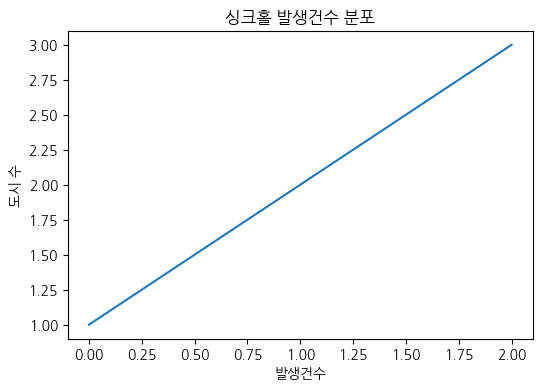

In [ ]:
# 한글폰트 확인용

plt.figure(figsize=(6,4))
plt.title("싱크홀 발생건수 분포")
plt.xlabel("발생건수")
plt.ylabel("도시 수")
plt.plot([1,2,3])
plt.show()

In [ ]:
# QGIS가 아닌 코드로 그리드 나눈후 그리드당 항목별 데이터 조인

import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from shapely.errors import TopologicalError
from dbfread import DBF

# ---------------------------------------------------------
# 0. QGIS에서 만든 250m GRID 불러오기
# ---------------------------------------------------------
grid = gpd.read_file("경기도250_5181.gpkg")   # ★ QGIS 250m grid
grid = grid.to_crs(epsg=5181)                   # 분석 좌표계 통일

print("Grid 개수:", len(grid))


# ---------------------------------------------------------
# 1. 싱크홀 발생지점 → GRID 카운팅
# ---------------------------------------------------------
df = pd.read_excel("싱크홀발생건수_위도경도_최종 (1).xls")

gdf_sink = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["경도"], df["위도"]),
    crs=4326
).to_crs(5181)

join = gpd.sjoin(gdf_sink, grid, how='left', predicate='within')
counts = join.groupby("index_right").size()

grid["sinkhole_count"] = grid.index.map(counts).fillna(0).astype(int)
grid["label"] = (grid["sinkhole_count"] > 0).astype(int)

print("싱크홀 매칭 완료")


# ---------------------------------------------------------
# 2. GRID centroid 계산
# ---------------------------------------------------------
grid["centroid"] = grid.geometry.centroid
grid_cent = grid.set_geometry("centroid")


# ---------------------------------------------------------
# 3. 단층 거리 계산
# ---------------------------------------------------------
fault = gpd.read_file("Geology_250K_Fault.shp").to_crs(5181)
fault_union = fault.unary_union

grid["dist_fault"] = grid["centroid"].distance(fault_union)

bins = [0, 1000, 2000, 3000, 5000, 1e12]
labels = [4, 3, 2, 1, 0]

grid["fault_risk_5"] = pd.cut(
    grid["dist_fault"], bins=bins, labels=labels, include_lowest=True
).astype(int)

print("단층 위험도 계산 완료")


# ---------------------------------------------------------
# 4. 기반암 정보 join
# ---------------------------------------------------------
table = DBF("Geology_250K_Litho.dbf", encoding="utf-8")
df_attr = pd.DataFrame(iter(table))

litho_geom = gpd.read_file("Geology_250K_Litho.shp")[["geometry"]]
litho = pd.concat([df_attr, litho_geom], axis=1)

litho = gpd.GeoDataFrame(litho, geometry="geometry", crs=4326).to_crs(5181)

# 경기도 clip
gyeonggi = grid.unary_union
litho_clip = litho[litho.intersects(gyeonggi)]

# 기반암 이름
litho_clip["bedrock"] = litho_clip["refrock"].fillna(litho_clip["lithoname"])

# centroid 기반 nearest join
litho_clip["centroid"] = litho_clip.geometry.centroid
litho_cent = litho_clip.set_geometry("centroid")

cent_join = grid_cent.sjoin_nearest(
    litho_cent[["bedrock", "centroid"]],
    how="left",
    distance_col="dist_litho"
)

grid["bedrock"] = cent_join["bedrock"]

risk_map = {
    "화강암": 0, "Granite": 0, "편마암": 0, "Gneiss": 0,
    "현무암": 1, "Basalt": 1,
    "사암": 2, "Sandstone": 2, "석회암": 2, "Limestone": 2,
    "역암": 2, "Conglomerate": 2,
    "셰일": 3, "Shale": 3,
    "이암": 4, "Mudstone": 4,
    "진흙": 5, "Clay": 5,
    "충적층": 6, "Alluvium": 6
}

def get_bedrock_risk(x):
    x = str(x)
    for key, val in risk_map.items():
        if key in x:
            return val
    return 3

grid["bedrock_risk"] = grid["bedrock"].apply(get_bedrock_risk)

print("기반암 위험도 계산 완료")


# ---------------------------------------------------------
# 5. 인구밀도 join
# ---------------------------------------------------------
pop = gpd.read_file("nlsp_017001001.shp").to_crs(5181)

pop["area_m2"] = pop.geometry.area
pop["pop_density_km2"] = pop["val"] / (pop["area_m2"] / 1_000_000)

grid_pop = gpd.sjoin(
    grid_cent,
    pop[["pop_density_km2", "geometry"]],
    how="left",
    predicate="within"
)

pop_agg = grid_pop.groupby(grid_pop.index)["pop_density_km2"].mean()
grid["pop_density_km2"] = pop_agg.fillna(0)

print("인구밀도 join 완료")


# ---------------------------------------------------------
# 6. 지하철 거리 계산
# ---------------------------------------------------------
subway = gpd.read_file("N3L_A0171119.shp").to_crs(5181)
subway_union = subway.unary_union

grid["dist_subway"] = grid["centroid"].distance(subway_union)

sub_bins = [0, 200, 500, 1000, 2000, 1e12]
sub_labels = [4, 3, 2, 1, 0]

grid["subway_risk_5"] = pd.cut(
    grid["dist_subway"], bins=sub_bins, labels=sub_labels, include_lowest=True
).astype(int)

print("지하철 위험도 계산 완료")


# ---------------------------------------------------------
# 7. 최종 결과 저장
# ---------------------------------------------------------
# grid = grid.drop(columns=["centroid"], errors="ignore")

# grid.to_file(
#     "grid_250m_final.gpkg",
#     layer="grid250",
#     driver="GPKG",
#     encoding="utf-8"
# )

# print("✔ 완료 : grid_250m_final.gpkg 저장됨")
# print("최종 grid 행수 =", len(grid))


Grid 개수: 167876
싱크홀 매칭 완료


/tmp/ipython-input-1231547666.py:48: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fault_union = fault.unary_union


단층 위험도 계산 완료


/tmp/ipython-input-1231547666.py:74: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gyeonggi = grid.unary_union
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


기반암 위험도 계산 완료
인구밀도 join 완료


/tmp/ipython-input-1231547666.py:140: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  subway_union = subway.unary_union


지하철 위험도 계산 완료


In [ ]:
grid = gpd.read_file('/content/full_df_1210-1.xlsx')

# grid.loc[grid['building_count'].isna(), :].reset_index(drop = True)
# prefix = "grid_250m_final — grid250_"

# grid.columns = grid.columns.str.replace(prefix, "", regex=False)

# grid['building_count'] = grid['building_count'].fillna(0)
# grid['building_coverage'] = grid['building_coverage'].fillna(0)

# grid['building_count'] = pd.to_numeric(grid['building_count'], errors='coerce')
# grid['building_coverage'] = pd.to_numeric(grid['building_coverage'], errors='coerce')
# grid['floor_area_ratio'] = pd.to_numeric(grid['floor_area_ratio'], errors='coerce')
# grid['building_height'] = pd.to_numeric(grid['building_height'], errors='coerce')
# grid['road_risk'] = pd.to_numeric(grid['road_risk'], errors='coerce')
# grid['new_gdf_합류식화율(%)'] = pd.to_numeric(grid['new_gdf_합류식화율(%)'], errors='coerce')
# grid['new_gdf_전체시설연장(m)/처리구역면적(㎢)'] = pd.to_numeric(grid['new_gdf_전체시설연장(m)/처리구역면적(㎢)'], errors='coerce')
# grid['new_gdf_분류식우수관시설연장(m)/행정구역면적(㎢)'] = pd.to_numeric(grid['new_gdf_분류식우수관시설연장(m)/행정구역면적(㎢)'], errors='coerce')
# grid['pipe_gdf_pipe_concrete_rate'] = pd.to_numeric(grid['pipe_gdf_pipe_concrete_rate'], errors='coerce')
# grid['pipe_gdf_pipe_plastic_rate'] = pd.to_numeric(grid['pipe_gdf_pipe_plastic_rate'], errors='coerce')
# grid['pipe_gdf_pipe_metal_rate'] = pd.to_numeric(grid['pipe_gdf_pipe_metal_rate'], errors='coerce')
# grid['sw_subset_전체보수(m)_전체(%)'] = pd.to_numeric(grid['sw_subset_전체보수(m)_전체(%)'], errors='coerce')
# grid['sw_subset_수밀검사/CCTV조사비율(시설연장기준)'] = pd.to_numeric(grid['sw_subset_수밀검사/CCTV조사비율(시설연장기준)'], errors='coerce')
# grid['sw_subset_전체보수(m)_분류식(우수)(%)'] = pd.to_numeric(grid['sw_subset_전체보수(m)_분류식(우수)(%)'], errors='coerce')
# grid['sw_subset_준설관로(m)_전체(%)'] = pd.to_numeric(grid['sw_subset_준설관로(m)_전체(%)'], errors='coerce')

# y = grid["label"].astype(int)

# # grid = grid[grid['SGG_NM'].notna()]
# # grid['SGG_NM'].isna().sum()

# # grid = grid[grid['DONG'].notna()]
# # grid['DONG'].isna().sum()

In [ ]:
grid

,id,SGG_NM,DONG,label,building_count,population,building_coverage_ratio,building_height,floor_area_ratio,litho_risk,...,perm,rain_sum,sw_rep_rt,sw_cctv,sw_rep_rn,sw_drg,sw_old_rt,sw_dens,rn_pp_dens,pp_conc
0,124860.0,의왕시,부곡동,0.0,4.0,321.0,58.89,20.51,274.32,1.0,...,0.000049,227.483333,0.000128,0.009634,0.000000,0.043803,23.700000,17370.868450,3478.625954,49.640229
1,124859.0,의왕시,부곡동,0.0,5.0,295.0,57.62,15.18,207.21,1.0,...,0.000048,227.483333,0.000128,0.009634,0.000000,0.043803,23.700000,17370.868450,3478.625954,49.640229
2,124858.0,의왕시,부곡동,0.0,0.0,0.0,0.00,0.00,0.00,1.0,...,0.000046,227.483333,0.000128,0.009634,0.000000,0.043803,23.700000,17370.868450,3478.625954,49.640229
3,124861.0,의왕시,부곡동,0.0,11.0,150.0,47.24,9.87,125.81,1.0,...,0.000051,227.483333,0.000128,0.009634,0.000000,0.043803,23.700000,17370.868450,3478.625954,49.640229
4,100706.0,고양시,행신2동,0.0,0.0,0.0,0.00,0.00,0.00,1.0,...,0.000021,239.138889,0.001013,0.002277,0.000304,0.052532,0.000000,40874.821369,6821.108044,43.882731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131323,114191.0,파주시,광탄면,0.0,0.0,0.0,0.00,0.00,0.00,1.0,...,1.628481,239.138889,0.000213,0.015033,0.000065,0.075563,66.666667,26900.192000,241.581998,29.128149
131324,114192.0,파주시,광탄면,0.0,0.0,0.0,0.00,0.00,0.00,1.0,...,1.607688,239.138889,0.000213,0.015033,0.000065,0.075563,66.666667,26900.192000,241.581998,29.128149
131325,114193.0,파주시,광탄면,0.0,0.0,0.0,0.00,0.00,0.00,1.0,...,1.617784,239.138889,0.000213,0.015033,0.000065,0.075563,66.666667,26900.192000,241.581998,29.128149
131326,114194.0,파주시,광탄면,0.0,0.0,0.0,0.00,0.00,0.00,1.0,...,1.627255,239.138889,0.000213,0.015033,0.000065,0.075563,66.666667,26900.192000,241.581998,29.128149


In [ ]:
grid.isna().sum().sort_values(ascending=False)

,0
id,0
SGG_NM,0
DONG,0
label,0
building_count,0
population,0
building_coverage_ratio,0
building_height,0
floor_area_ratio,0
litho_risk,0


In [ ]:
# 시군별 발생건수 집계
city_event = grid.groupby("SGG_NM")["label"].sum().reset_index()
city_event.columns = ["city", "event_count"]

city_event

,city,event_count
0,가평군,0.0
1,고양시,33.0
2,과천시,8.0
3,광명시,1.0
4,광주시,1.0
5,구리시,7.0
6,군포시,4.0
7,김포시,2.0
8,남양주시,17.0
9,동두천시,1.0


Low group:
    city  event_count
0    가평군            0
3    광명시            1
4    광주시            1
6    군포시            4
7    김포시            2
9   동두천시            1
15   안성시            2
18   양평군            0
20   연천군            0
21   오산시            3
28   포천시            4
29   하남시            4

Middle group (테스트 후보):
    city  event_count
2    과천시            8
5    구리시            7
11   성남시            6
13   시흥시            6
14   안산시            6
16   안양시            7
17   양주시            6
19   여주시            6
24  의정부시            7
26   파주시            6

High group:
    city  event_count
1    고양시           33
8   남양주시           17
10   부천시           57
12   수원시           11
22   용인시           10
23   의왕시           13
25   이천시           14
27   평택시           11
30   화성시           34
30% Quantile (Q30): 4.0
50% Quantile (Median): 6.0
70% Quantile (Q70): 8.0


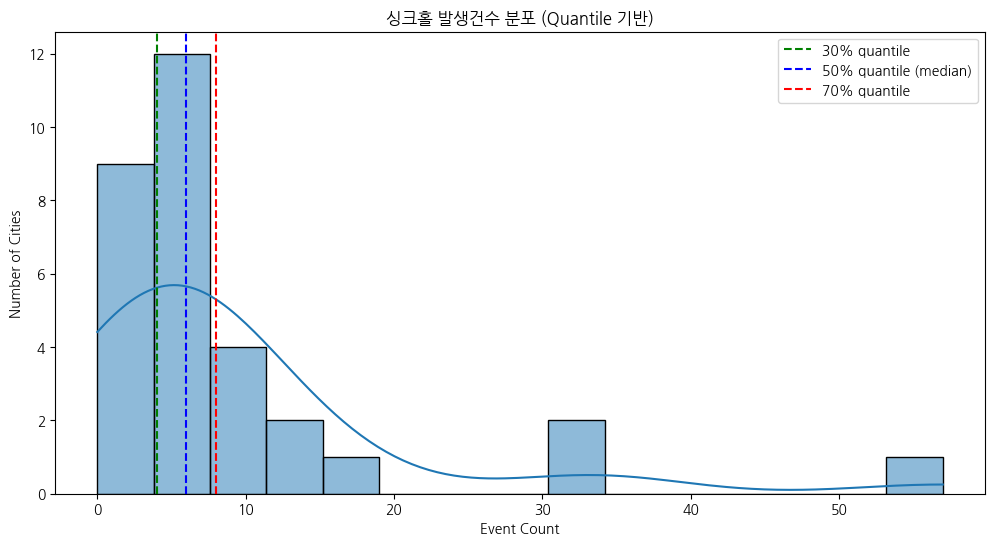

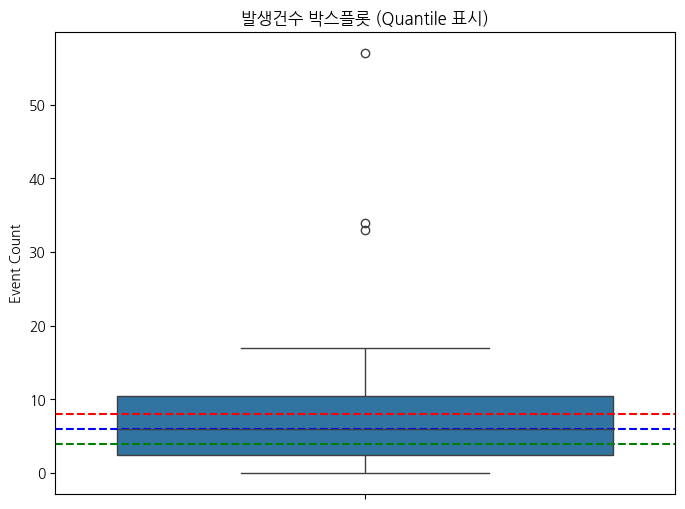

In [ ]:
# 발생건수 시각화

q30 = city_event["event_count"].quantile(0.30)
q70 = city_event["event_count"].quantile(0.70)

low_group = city_event[city_event["event_count"] <= q30]
mid_group = city_event[(city_event["event_count"] > q30) & (city_event["event_count"] <= q70)]
high_group = city_event[city_event["event_count"] > q70]

print("Low group:")
print(low_group)

print("\nMiddle group (테스트 후보):")
print(mid_group)

print("\nHigh group:")
print(high_group)

import seaborn as sns
import matplotlib.pyplot as plt

# 1) 시군별 발생건수 집계
city_event = grid.groupby("SGG_NM")["label"].sum().reset_index()
city_event.columns = ["city", "event_count"]

# 2) quantile 계산
q30 = city_event["event_count"].quantile(0.30)
q50 = city_event["event_count"].quantile(0.50)
q70 = city_event["event_count"].quantile(0.70)

print("30% Quantile (Q30):", q30)
print("50% Quantile (Median):", q50)
print("70% Quantile (Q70):", q70)

# 3) 히스토그램 + quantile 라인 표시
plt.figure(figsize=(12, 6))
sns.histplot(city_event["event_count"], kde=True, bins=15)
plt.axvline(q30, color='green', linestyle='--', label='30% quantile')
plt.axvline(q50, color='blue', linestyle='--', label='50% quantile (median)')
plt.axvline(q70, color='red', linestyle='--', label='70% quantile')
plt.title("싱크홀 발생건수 분포 (Quantile 기반)")
plt.xlabel("Event Count")
plt.ylabel("Number of Cities")
plt.legend()
plt.show()

# 4) 박스플롯 + quantile 라인 표시
plt.figure(figsize=(8, 6))
sns.boxplot(y=city_event["event_count"])
plt.axhline(q30, color='green', linestyle='--')
plt.axhline(q50, color='blue', linestyle='--')
plt.axhline(q70, color='red', linestyle='--')
plt.title("발생건수 박스플롯 (Quantile 표시)")
plt.ylabel("Event Count")
plt.show()


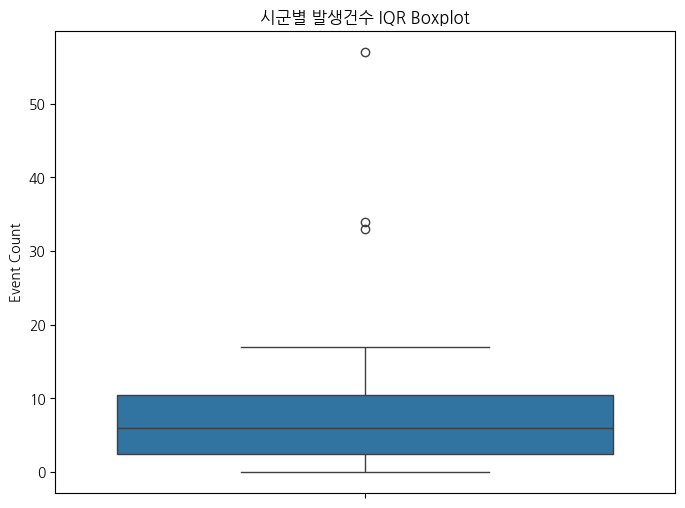

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(y=city_event["event_count"])
plt.title("시군별 발생건수 IQR Boxplot")
plt.ylabel("Event Count")
plt.show()


In [ ]:
# IQR 계산
Q1 = city_event["event_count"].quantile(0.25)
Q3 = city_event["event_count"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

low_group = city_event[city_event["event_count"] < lower_bound]
middle_group = city_event[(city_event["event_count"] >= lower_bound) & (city_event["event_count"] <= upper_bound)]
high_group = city_event[city_event["event_count"] > upper_bound]

print("🔵 Low group (이상치 낮은쪽):")
print(low_group)

print("\n🟢 Middle group (IQR 내부 = 테스트 후보):")
print(middle_group)

print("\n🔴 High group (이상치 높은쪽):")
print(high_group)

Q1: 2.5
Q3: 10.5
IQR: 8.0
Lower bound: -9.5
Upper bound: 22.5


발생 0건 시군: ['가평군', '양평군', '연천군']
발생 시군 수: 28
✅ 최종 훈련 데이터 크기: (113832, 37)
✅ 최종 테스트 데이터 크기: (17496, 37)
Train 포함 시군 수: 25
Test 포함 시군 수 : 6

🚫 Test에 발생 0건 시군 포함 여부: set()

Train 발생 비율:
label
0    0.998428
1    0.001572
Name: proportion, dtype: float64

Test 발생 비율:
label
0    0.993827
1    0.006173
Name: proportion, dtype: float64

====================== Middle Group 전체 테스트 결과 ======================
Accuracy : 0.8877457704618198
Precision: 0.041954590325765054
Recall   : 0.7870370370370371
F1-score : 0.07966260543580131
ROC-AUC  : 0.9086835642290554
PR-AUC   : 0.05759922999075636

혼동행렬:
       예측 0  예측 1
실제 0  15447  1941
실제 1     23    85


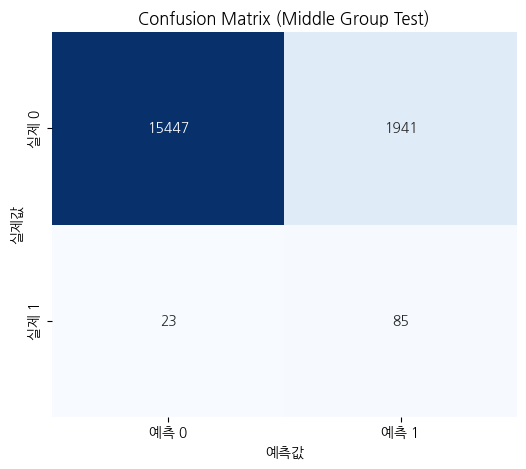

/tmp/ipython-input-4104026402.py:296: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


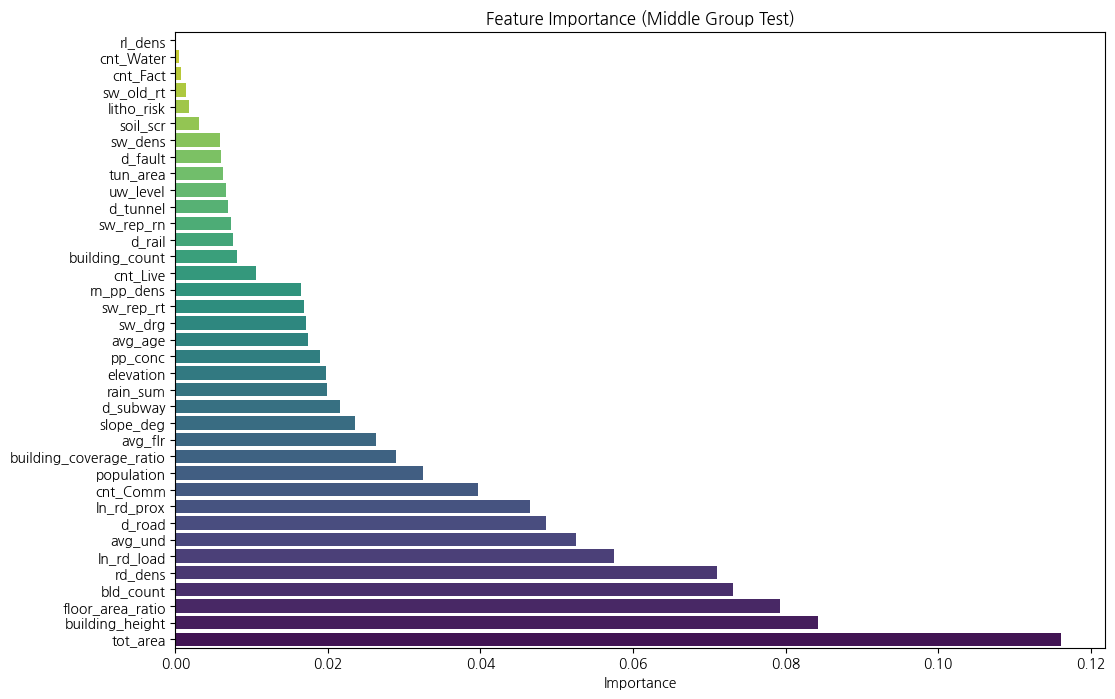

In [ ]:
# BRF최종_모델--------------------
# ================================
# Middle Group 전체를 TEST로 사용
# ================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.ensemble import BalancedRandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve

# ================================
# 1) 기본     Feature 목록
# ================================
features = ['building_count', 'population',
       'building_coverage_ratio', 'building_height', 'floor_area_ratio',
       'litho_risk', 'd_fault', 'd_road', 'rd_dens',
       'ln_rd_load', 'ln_rd_prox', 'd_tunnel', 'tun_area', 'd_subway',
       'd_rail', 'rl_dens', 'elevation', 'slope_deg', 'bld_count', 'tot_area',
       'avg_flr', 'avg_age', 'avg_und', 'cnt_Comm', 'cnt_Fact'
       , 'cnt_Live', 'cnt_Water', 'soil_scr', 'uw_level'
       , 'rain_sum', 'sw_rep_rt', 'sw_rep_rn', 'sw_drg',
       'sw_old_rt', 'sw_dens', 'rn_pp_dens', 'pp_conc']

# pos = grid[grid["label"] == 1]
# neg = grid[grid["label"] == 0].sample(
#     len(pos) * 2,   # 1:2 비율이면 *2, 1:1이면 *1
#     random_state=42
# )

df = grid[features].apply(pd.to_numeric, errors="coerce")
# df = pd.concat([pos, neg]).sample(frac=1, random_state=42).reset_index(drop=True)

X = df[features]
y = grid["label"]

# # ================================
# # 2) 상관관계 Heatmap (참고용)
# # ================================
# corr_matrix = df.corr()

# plt.figure(figsize=(18, 16))
# sns.heatmap(corr_matrix, annot=True,          # ★ 모든 칸에 수치 표시
#     fmt=".2f", cmap='coolwarm', linewidths=0.5)
# plt.title("📌 독립변수 간 상관관계 Heatmap", fontsize=20)
# plt.show()

# print("\n📌 상관계수 계산 완료")

# # ================================
# # 3) VIF 계산 → 삭제 대상 결정
# # ================================
# df_vif = df.dropna()
# vif_data = pd.DataFrame()
# vif_data["feature"] = df_vif.columns
# vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i)
#                    for i in range(df_vif.shape[1])]

# print("\n🟢 VIF 결과:")
# print(vif_data.sort_values("VIF", ascending=False))

# # 🔥 VIF 기준 설정 (일반적으로 10 이상 제거)
# vif_threshold = 10

# remove_list = vif_data[vif_data["VIF"] > vif_threshold]["feature"].tolist()
# print("\n🔴 VIF 기준 초과로 제거할 변수:", remove_list)

# # ================================
# # 4) 최종 features 결정
# # ================================
# cleaned_features = [f for f in features if f not in remove_list]

# print("\n📌 최종 사용될 변수 개수:", len(cleaned_features))
# print("📌 최종 Feature 목록:", cleaned_features)

# ================================
# 5) Middle Group 산정
# ================================

# 시군별 발생건수 집계
city_event = grid.groupby("SGG_NM")["label"].sum().reset_index()
city_event.columns = ["city", "event_count"]

# 🔴 [추가] 발생건수 0인 시군 제외
zero_cities = city_event[city_event["event_count"] == 0]["city"].tolist()

# 발생 있는 시군 (Train/Test 대상)
nonzero_cities = city_event[city_event["event_count"] > 0]["city"].tolist()

print("발생 0건 시군:", zero_cities)
print("발생 시군 수:", len(nonzero_cities))

# # 🔥 quantile 계산 및 Middle Group 산정을 위해 발생0 도시 제거
# city_event_nonzero = city_event[city_event["event_count"] > 0]

# # 🔴 [수정] quantile 계산도 nonzero 기준으로
# q30 = city_event_nonzero["event_count"].quantile(0.30)
# q70 = city_event_nonzero["event_count"].quantile(0.70)

# # 🔴 [수정] Middle Group도 nonzero 기준으로 생성
# middle_group = city_event_nonzero[
#     (city_event_nonzero["event_count"] > q30) &
#     (city_event_nonzero["event_count"] <= q70)
# ]

# 30%, 70% quantile 계산
# q30 = city_event["event_count"].quantile(0.30)
# q70 = city_event["event_count"].quantile(0.70)

# # Middle Group = 테스트 후보
# middle_group = city_event[(city_event["event_count"] > q30) &
#                           (city_event["event_count"] <= q70)]

# print("🟢 Middle Group 테스트 도시들:")
# print(middle_group)

# # Middle Group 도시 리스트
# test_cities = middle_group["city"].tolist()

# # Middle Group 제거 + 발생 0 도시 제거 → 훈련 인덱스
# train_idx = (~grid["SGG_NM"].isin(test_cities)) & (~grid["SGG_NM"].isin(zero_cities))

# # 적용
# X_train = grid.loc[train_idx, cleaned_features].apply(pd.to_numeric, errors="coerce")
# y_train = grid.loc[train_idx, "label"].astype(int)

# # 테스트셋 (Middle Group만)
# test_idx = grid["SGG_NM"].isin(test_cities)
# X_test = grid.loc[test_idx, cleaned_features].apply(pd.to_numeric, errors="coerce")
# y_test = grid.loc[test_idx, "label"].astype(int)


# 테스트 인덱스
# test_idx = grid["SGG_NM"].isin(test_cities)

# 3개군 제거
# 상관관계 제거
# # 훈련/테스트 분리
# X_train = grid.loc[~test_idx, cleaned_features].apply(pd.to_numeric, errors="coerce")
# y_train = grid.loc[~test_idx, "label"].astype(int)

# X_test  = grid.loc[test_idx, cleaned_features].apply(pd.to_numeric, errors="coerce")
# y_test  = grid.loc[test_idx, "label"].astype(int)

# 상관관계 미제거
# 훈련/테스트 분리
# X_train = grid.loc[~test_idx, features].apply(pd.to_numeric, errors="coerce")
# y_train = grid.loc[~test_idx, "label"].astype(int)

# X_test  = grid.loc[test_idx, features].apply(pd.to_numeric, errors="coerce")
# y_test  = grid.loc[test_idx, "label"].astype(int)

# X_all = grid[features].apply(pd.to_numeric, errors="coerce")
# y_all = grid["label"].astype(int)

# X_train, X_test, y_train, y_test = train_test_split(
#     X_all,
#     y_all,
#     test_size=0.2,
#     stratify=y_all,
#     random_state=42
# )


# # ❌ 발생 0건 군 제거 (Test 후보)
# grid_test_candidate = grid[~grid["SGG_NM"].isin(zero_cities)].copy()

# X_tc = grid_test_candidate[features].apply(pd.to_numeric, errors="coerce")
# y_tc = grid_test_candidate["label"].astype(int)


# #튜닝
# X_train_tc, X_test, y_train_tc, y_test = train_test_split(
#     X_tc,
#     y_tc,
#     test_size=0.2,      # ✅ 8:2
#     stratify=y_tc,      # ✅ 클래스 비율 유지
#     random_state=42
# )

# # 발생 0건 군 데이터
# grid_zero = grid[grid["SGG_NM"].isin(zero_cities)]

# X_zero = grid_zero[features].apply(pd.to_numeric, errors="coerce")
# y_zero = grid_zero["label"].astype(int)

# # ✅ 최종 Train = (Test 후보 중 80%) + (0건 군 전체)
# X_train = pd.concat([X_train_tc, X_zero], axis=0)
# y_train = pd.concat([y_train_tc, y_zero], axis=0)


train_cities, test_cities = train_test_split(
    nonzero_cities,
    test_size=0.2,     # ✅ 시군 기준 8:2
    random_state=42
)

# ✅ Train = (발생 시군 중 80%) + (발생 0건 시군 전체)
train_idx = grid["SGG_NM"].isin(train_cities + zero_cities)

# ✅ Test = 발생 시군 중 20%만
test_idx = grid["SGG_NM"].isin(test_cities)

X_train = grid.loc[train_idx, features].apply(pd.to_numeric, errors="coerce")
y_train = grid.loc[train_idx, "label"].astype(int)

X_test  = grid.loc[test_idx, features].apply(pd.to_numeric, errors="coerce")
y_test  = grid.loc[test_idx, "label"].astype(int)

print("✅ 최종 훈련 데이터 크기:", X_train.shape)
print("✅ 최종 테스트 데이터 크기:", X_test.shape)

print("Train 포함 시군 수:", grid.loc[X_train.index, "SGG_NM"].nunique())
print("Test 포함 시군 수 :", grid.loc[X_test.index, "SGG_NM"].nunique())

print("\n🚫 Test에 발생 0건 시군 포함 여부:",
      set(test_cities) & set(zero_cities))

print("\nTrain 발생 비율:")
print(y_train.value_counts(normalize=True))

print("\nTest 발생 비율:")
print(y_test.value_counts(normalize=True))

# 모델 학습
model = BalancedRandomForestClassifier(
    n_estimators=410,
    max_depth=4,
    min_samples_leaf=9,          # ★ leaf 작게 → 작은 패턴도 잡음 → recall ↑
    # class_weight="balanced",     # 안정적
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

threshold = 0.73

# 예측
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

# 성능 출력
pr_auc = average_precision_score(y_test, y_prob)

print("\n====================== Middle Group 전체 테스트 결과 ======================")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", pr_auc)

# ================================
# Confusion Matrix 출력 + 시각화
# ================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['실제 0', '실제 1'],
    columns=['예측 0', '예측 1']
)

print("\n혼동행렬:")
print(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix (Middle Group Test)")
plt.xlabel("예측값")
plt.ylabel("실제값")
plt.show()

# ================================
# Feature Importance 시각화
# ================================
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]  # 큰 순서대로 정렬

# plt.figure(figsize=(12, 8))
# sns.barplot(
#     x=importances[indices],
#     y=np.array(cleaned_features)[indices],
#     palette="viridis"
# )

plt.figure(figsize=(12, 8))
sns.barplot(
    x=importances[indices],
    y=np.array(features)[indices],
    palette="viridis"
)

# plt.barh(cleaned_features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Middle Group Test)")
plt.gca().invert_yaxis()  # 보기 좋게 위부터 정렬
plt.show()

In [ ]:
# 파라미터 조정

import itertools
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# ===========================================================
# 1) 파라미터 후보 범위
# ===========================================================
param_grid = {
    # 🔥 트리 수: 250 ~ 500 (10 단위)
    "n_estimators": list(range(250, 501, 10)),
    "max_depth": [4, 5, 6, 7, 8],
    "min_samples_leaf": [7, 8, 9, 10, 12, 15]
}

threshold_list = np.round(np.arange(0.50, 0.91, 0.01), 2)

results = []

# ===========================================================
# 2) 파라미터 조합 + threshold 조합 전체 탐색
# ===========================================================
for n_est, depth, leaf in itertools.product(
    param_grid["n_estimators"],
    param_grid["max_depth"],
    param_grid["min_samples_leaf"]
):
    print(f"\n=== 모델 학습 중: n_estimators={n_est}, max_depth={depth}, leaf={leaf} ===")

    model = BalancedRandomForestClassifier(
        n_estimators=n_est,
        max_depth=depth,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # 확률 예측
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob  = model.predict_proba(X_test)[:, 1]

    auc_train = roc_auc_score(y_train, y_train_prob)
    auc_test  = roc_auc_score(y_test,  y_test_prob)

    # 🔥 PR-AUC (Average Precision)
    pr_auc_train = average_precision_score(y_train, y_train_prob)
    pr_auc_test  = average_precision_score(y_test,  y_test_prob)

    # ------------------------------
    # threshold loop
    # ------------------------------
    for thr in threshold_list:

        y_train_pred = (y_train_prob >= thr).astype(int)
        y_test_pred  = (y_test_prob  >= thr).astype(int)

        # Train metrics
        acc_tr  = accuracy_score(y_train, y_train_pred)
        prec_tr = precision_score(y_train, y_train_pred, zero_division=0)
        rec_tr  = recall_score(y_train, y_train_pred, zero_division=0)
        f1_tr   = f1_score(y_train, y_train_pred, zero_division=0)

        # Test metrics
        acc_te  = accuracy_score(y_test, y_test_pred)
        prec_te = precision_score(y_test, y_test_pred, zero_division=0)
        rec_te  = recall_score(y_test, y_test_pred, zero_division=0)
        f1_te   = f1_score(y_test, y_test_pred, zero_division=0)

        results.append({
            "n_estimators": n_est,
            "max_depth": depth,
            "min_samples_leaf": leaf,
            "threshold": thr,
            "acc_train": acc_tr,
            "prec_train": prec_tr,
            "recall_train": rec_tr,
            "f1_train": f1_tr,
            "auc_train": auc_train,
            "pr_auc_train": pr_auc_train,
            "acc_test": acc_te,
            "prec_test": prec_te,
            "recall_test": rec_te,
            "f1_test": f1_te,
            "auc_test": auc_test,
            "pr_auc_test": pr_auc_test,
            "auc_gap": auc_train - auc_test
        })

# ===========================================================
# 3) 결과 DF 정리
# ===========================================================
results_df = pd.DataFrame(results)

print("\n================= 전체 모델 탐색 결과 (상위 20개 AUC 기준) =================")
print(results_df.sort_values("auc_test", ascending=False).head(20))


# ===========================================================
# 4) 민수 기준 필터링
# ===========================================================
candidates = results_df[
    (results_df["recall_test"] >= 0.70) &
    (results_df["prec_test"] >= 0.04) &                # 오타 prec→prec_test 고침
    (results_df["f1_test"] >= 0.02) &
    (results_df["auc_test"] >= 0.80)&
    (results_df["pr_auc_test"] >= 0.05)
].copy()

print("\n================= 조건 만족 후보 모델 =================")
if candidates.empty:
    print("❌ 조건 만족 모델 없음 — 파라미터 또는 threshold 조건을 약간 완화하세요.")
else:
    print(candidates.sort_values(["auc_test", "recall_test"], ascending=False))


# ===========================================================
# 5) 최종 베스트 모델 선택
# ===========================================================
if not candidates.empty:
    best_row = candidates.sort_values(
        ["auc_test", "recall_test", "prec_test"],
        ascending=False
    ).iloc[0]
else:
    # 후보가 없다면 auc_test 최고 모델로 선정
    best_row = results_df.sort_values("auc_test", ascending=False).iloc[0]

print("\n================= 최종 선택된 베스트 모델 =================")
print(best_row)

best_params = {
    "n_estimators": int(best_row["n_estimators"]),
    "max_depth": int(best_row["max_depth"]),
    "min_samples_leaf": int(best_row["min_samples_leaf"]),
    "threshold": float(best_row["threshold"])
}

print("\n최종 선택 파라미터 + Threshold:", best_params)


# ===========================================================
# 6) 최종 모델 재학습 + Test 성능 출력
# ===========================================================
final_model = BalancedRandomForestClassifier(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

y_test_prob_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_test_prob_final >= best_params["threshold"]).astype(int)

print("\n================= 최종 모델 Test 성능 =================")
print("Threshold :", best_params["threshold"])
print("Accuracy  :", accuracy_score(y_test, y_pred_final))
print("Precision :", precision_score(y_test, y_pred_final, zero_division=0))
print("Recall    :", recall_score(y_test, y_pred_final, zero_division=0))
print("F1-score  :", f1_score(y_test, y_pred_final, zero_division=0))
print("ROC-AUC   :", roc_auc_score(y_test, y_test_prob_final))
print("PR-AUC    :", average_precision_score(y_test, y_test_prob_final))

# ===========================================================
# 🔥 최종 TOP 10 모델 (재현율 + PR-AUC 기준)
# ===========================================================

top10 = (
    results_df
    .query("pr_auc_test >= 0.05")
    .sort_values(
        by=["recall_test", "pr_auc_test", "prec_test"],
        ascending=[False, False, False]
    )
    .head(10)
)

print("\n================= PR-AUC ≥ 0.05 + Recall 기준 TOP 10 =================")
print(top10[[
    "n_estimators",
    "max_depth",
    "min_samples_leaf",
    "threshold",
    "recall_test",
    "pr_auc_test",
    "prec_test",
    "f1_test",
    "auc_test"
]])



=== 모델 학습 중: n_estimators=250, max_depth=4, leaf=7 ===

=== 모델 학습 중: n_estimators=250, max_depth=4, leaf=8 ===

=== 모델 학습 중: n_estimators=250, max_depth=4, leaf=9 ===

=== 모델 학습 중: n_estimators=250, max_depth=4, leaf=10 ===

=== 모델 학습 중: n_estimators=250, max_depth=4, leaf=12 ===

=== 모델 학습 중: n_estimators=250, max_depth=4, leaf=15 ===

=== 모델 학습 중: n_estimators=250, max_depth=5, leaf=7 ===

=== 모델 학습 중: n_estimators=250, max_depth=5, leaf=8 ===

=== 모델 학습 중: n_estimators=250, max_depth=5, leaf=9 ===

=== 모델 학습 중: n_estimators=250, max_depth=5, leaf=10 ===

=== 모델 학습 중: n_estimators=250, max_depth=5, leaf=12 ===

=== 모델 학습 중: n_estimators=250, max_depth=5, leaf=15 ===

=== 모델 학습 중: n_estimators=250, max_depth=6, leaf=7 ===

=== 모델 학습 중: n_estimators=250, max_depth=6, leaf=8 ===

=== 모델 학습 중: n_estimators=250, max_depth=6, leaf=9 ===

=== 모델 학습 중: n_estimators=250, max_depth=6, leaf=10 ===

=== 모델 학습 중: n_estimators=250, max_depth=6, leaf=12 ===

=== 모델 학습 중: n_estimators=250, max_dept

In [ ]:
from sklearn.metrics import precision_recall_curve

probs = model.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, probs)

results = pd.DataFrame({
    "threshold": np.append(thr, 1),
    "precision": prec,
    "recall": rec
})

# 조건 만족하는 지점 필터링
candidates = results[
    (results["precision"] >= 0.01) &
    (results["recall"] >= 0.70)
]

candidates.sort_values("precision", ascending=False).head()


,threshold,precision,recall
14144,0.781894,0.051887,0.712963
14143,0.781815,0.051852,0.712963
14162,0.783877,0.051842,0.703704
14142,0.781758,0.051817,0.712963
14161,0.783585,0.051806,0.703704


발생 0건 시군: ['가평군', '양평군', '연천군']
발생 시군 수: 28
✅ 최종 훈련 데이터 크기: (113832, 37)
✅ 최종 테스트 데이터 크기: (17496, 37)
Train 포함 시군 수: 25
Test 포함 시군 수 : 6

🚫 Test에 발생 0건 시군 포함 여부: set()

Train 발생 비율:
label
0    0.998428
1    0.001572
Name: proportion, dtype: float64

Test 발생 비율:
label
0    0.993827
1    0.006173
Name: proportion, dtype: float64

====================== Logistic Regression 테스트 결과 ======================
Accuracy : 0.906092821216278
Precision: 0.0471976401179941
Recall   : 0.7407407407407407
F1-score : 0.08874098724348309
ROC-AUC  : 0.9001573030357249
PR-AUC   : 0.10810523976339509

혼동행렬:
       예측 0  예측 1
실제 0  15773  1615
실제 1     28    80


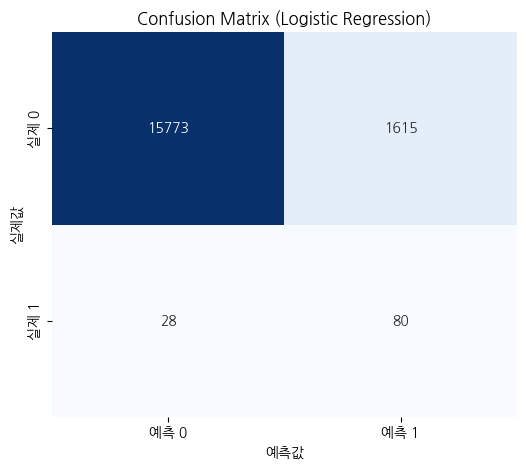


📌 Logistic Regression 변수 영향력 (절대값 기준):
             feature      coef  abs_coef
7             d_road -1.737074  1.737074
30         sw_rep_rt  1.086959  1.086959
31         sw_rep_rn -0.744800  0.744800
29          rain_sum -0.611750  0.611750
16         elevation -0.496073  0.496073
13          d_subway -0.405160  0.405160
18         bld_count  0.394966  0.394966
34           sw_dens -0.311159  0.311159
4   floor_area_ratio  0.306125  0.306125
8            rd_dens  0.285667  0.285667
25          cnt_Live -0.277380  0.277380
21           avg_age  0.235758  0.235758
23          cnt_Comm  0.212836  0.212836
28          uw_level -0.154330  0.154330
36           pp_conc  0.145028  0.145028


In [ ]:
# ================================
# Logistic Regression 모델
# ================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix
)

features = ['building_count', 'population',
       'building_coverage_ratio', 'building_height', 'floor_area_ratio',
       'litho_risk', 'd_fault', 'd_road', 'rd_dens',
       'ln_rd_load', 'ln_rd_prox', 'd_tunnel', 'tun_area', 'd_subway',
       'd_rail', 'rl_dens', 'elevation', 'slope_deg', 'bld_count', 'tot_area',
       'avg_flr', 'avg_age', 'avg_und', 'cnt_Comm', 'cnt_Fact'
       , 'cnt_Live', 'cnt_Water', 'soil_scr', 'uw_level'
       , 'rain_sum', 'sw_rep_rt', 'sw_rep_rn', 'sw_drg',
       'sw_old_rt', 'sw_dens', 'rn_pp_dens', 'pp_conc']

df = grid[features].apply(pd.to_numeric, errors="coerce")

X = df[features]
y = grid["label"]

city_event = grid.groupby("SGG_NM")["label"].sum().reset_index()
city_event.columns = ["city", "event_count"]

# 🔴 [추가] 발생건수 0인 시군 제외
zero_cities = city_event[city_event["event_count"] == 0]["city"].tolist()

# 발생 있는 시군 (Train/Test 대상)
nonzero_cities = city_event[city_event["event_count"] > 0]["city"].tolist()

print("발생 0건 시군:", zero_cities)
print("발생 시군 수:", len(nonzero_cities))

train_cities, test_cities = train_test_split(
    nonzero_cities,
    test_size=0.2,     # ✅ 시군 기준 8:2
    random_state=42
)

# ✅ Train = (발생 시군 중 80%) + (발생 0건 시군 전체)
train_idx = grid["SGG_NM"].isin(train_cities + zero_cities)

# ✅ Test = 발생 시군 중 20%만
test_idx = grid["SGG_NM"].isin(test_cities)

X_train = grid.loc[train_idx, features].apply(pd.to_numeric, errors="coerce")
y_train = grid.loc[train_idx, "label"].astype(int)

X_test  = grid.loc[test_idx, features].apply(pd.to_numeric, errors="coerce")
y_test  = grid.loc[test_idx, "label"].astype(int)

print("✅ 최종 훈련 데이터 크기:", X_train.shape)
print("✅ 최종 테스트 데이터 크기:", X_test.shape)

print("Train 포함 시군 수:", grid.loc[X_train.index, "SGG_NM"].nunique())
print("Test 포함 시군 수 :", grid.loc[X_test.index, "SGG_NM"].nunique())

print("\n🚫 Test에 발생 0건 시군 포함 여부:",
      set(test_cities) & set(zero_cities))

print("\nTrain 발생 비율:")
print(y_train.value_counts(normalize=True))

print("\nTest 발생 비율:")
print(y_test.value_counts(normalize=True))

# ================================
# 1) Pipeline 구성
#    - Logistic은 스케일링 필수
# ================================

logi_model = Pipeline([
    ("scaler", StandardScaler()),   # ★ 중요
    ("logi", LogisticRegression(
        penalty="l2",               # 기본
        C=0.01,                      # 🔥 규제 강도 (작을수록 보수적)
        solver="liblinear",         # 소규모/불균형 안정
        class_weight="balanced",    # 🔥 불균형 보정 핵심
        max_iter=2000,
        random_state=42
    ))
])

# ================================
# 2) 모델 학습
# ================================

logi_model.fit(X_train, y_train)

# ================================
# 3) Threshold 적용 예측
# ================================

threshold = 0.90   # BRF와 동일 기준 비교

y_prob = logi_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

# ================================
# 4) 성능 평가
# ================================

pr_auc = average_precision_score(y_test, y_prob)

print("\n====================== Logistic Regression 테스트 결과 ======================")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", pr_auc)

# ================================
# 5) Confusion Matrix
# ================================

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["실제 0", "실제 1"],
    columns=["예측 0", "예측 1"]
)

print("\n혼동행렬:")
print(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("예측값")
plt.ylabel("실제값")
plt.show()

# ================================
# Logistic Regression 계수 확인
# ================================

coef = logi_model.named_steps["logi"].coef_[0]

coef_df = pd.DataFrame({
    "feature": features,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("\n📌 Logistic Regression 변수 영향력 (절대값 기준):")
print(coef_df.head(15))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, average_precision_score

# ================================
# 1) Pipeline
# ================================

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logi", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

# ================================
# 2) Param Grid
# ================================

param_grid = {
    "logi__penalty": ["l1", "l2"],
    "logi__C": [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 3.0],
    "logi__solver": ["liblinear"]  # l1 지원 + 안정
}

pr_auc_scorer = make_scorer(
    average_precision_score,
    needs_proba=True
)

logi_grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=pr_auc_scorer,   # 🔥 핵심
    cv=5,                   # StratifiedKFold 자동
    n_jobs=-1,
    verbose=2
)

logi_grid.fit(X_train, y_train)

print("\n✅ Best PR-AUC (CV):", logi_grid.best_score_)
print("✅ Best Params:")
print(logi_grid.best_params_)

best_logi = logi_grid.best_estimator_

threshold = 0.88  # BRF와 동일 기준 비교

y_prob = best_logi.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

print("\n================ Logistic Regression (GridSearch) Test =================")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", average_precision_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("\n혼동행렬:")
print(pd.DataFrame(cm, index=["실제 0", "실제 1"], columns=["예측 0", "예측 1"]))

results_df = pd.DataFrame(logi_grid.cv_results_)

cols = [
    "mean_test_score",
    "param_logi__C",
    "param_logi__penalty"
]

print(
    results_df[cols]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.5, 0.91, 0.02)

rows = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "predicted_positives": y_pred_t.sum()
    })

thr_df = pd.DataFrame(rows)

print(thr_df)


    threshold  precision    recall        f1  predicted_positives
0        0.50   0.018432  0.879630  0.036108                 5154
1        0.52   0.018959  0.870370  0.037110                 4958
2        0.54   0.019706  0.870370  0.038540                 4770
3        0.56   0.020235  0.861111  0.039541                 4596
4        0.58   0.021069  0.861111  0.041132                 4414
5        0.60   0.022017  0.861111  0.042936                 4224
6        0.62   0.023054  0.861111  0.044906                 4034
7        0.64   0.024175  0.861111  0.047029                 3847
8        0.66   0.025265  0.861111  0.049089                 3681
9        0.68   0.026384  0.851852  0.051182                 3487
10       0.70   0.027626  0.842593  0.053498                 3294
11       0.72   0.029498  0.842593  0.057000                 3085
12       0.74   0.031034  0.833333  0.059840                 2900
13       0.76   0.032553  0.824074  0.062632                 2734
14       0

In [ ]:
# brf, 로지스틱회귀 융합 모델 파라미터 조정

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
import pandas as pd
import numpy as np

def eval_pred(name, y_true, y_prob, y_pred):
    return {
        "model": name,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "pred_pos": int(y_pred.sum())
    }

# 확률
p_brf  = model.predict_proba(X_test)[:, 1]
p_logi = logi_model.predict_proba(X_test)[:, 1]

# 단일 모델 기준
t_brf, t_logi = 0.73, 0.80
pred_brf  = (p_brf  >= t_brf).astype(int)
pred_logi = (p_logi >= t_logi).astype(int)

# 조합
pred_and = ((pred_brf == 1) & (pred_logi == 1)).astype(int)
pred_or  = ((pred_brf == 1) | (pred_logi == 1)).astype(int)

# 2단계 게이트 (BRF 후보 넓게, 로지로 확정)
cand = (p_brf >= 0.60)
pred_gate = np.zeros_like(pred_brf)
pred_gate[cand] = (p_logi[cand] >= t_logi).astype(int)

# 조합 확률(평가용): 간단히 평균 사용 (게이트는 cand 기반으로)
prob_mean = (p_brf + p_logi) / 2
prob_and  = np.minimum(p_brf, p_logi)   # AND 느낌
prob_or   = np.maximum(p_brf, p_logi)   # OR 느낌
prob_gate = p_logi.copy()
prob_gate[~cand] = 0.0

results = [
    eval_pred("BRF", y_test, p_brf, pred_brf),
    eval_pred("LOGI", y_test, p_logi, pred_logi),
    eval_pred("AND", y_test, prob_and, pred_and),
    eval_pred("OR",  y_test, prob_or,  pred_or),
    eval_pred("GATE",y_test, prob_gate,pred_gate),
]

res_df = pd.DataFrame(results).sort_values(["recall","precision"], ascending=False)
print(res_df)

print("\nConfusion Matrix (GATE):\n", confusion_matrix(y_test, pred_gate))


  model  precision    recall        f1   roc_auc    pr_auc  pred_pos
3    OR   0.031493  0.861111  0.060764  0.919464  0.109429      2953
1  LOGI   0.035583  0.805556  0.068155  0.900157  0.108105      2445
0   BRF   0.041955  0.787037  0.079663  0.908684  0.057599      2026
4  GATE   0.040547  0.768519  0.077030  0.876140  0.108762      2047
2   AND   0.052042  0.731481  0.097171  0.892642  0.057198      1518

Confusion Matrix (GATE):
 [[15424  1964]
 [   25    83]]


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix
)

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

features = ['building_count', 'population',
       'building_coverage_ratio', 'building_height', 'floor_area_ratio',
       'litho_risk', 'd_fault', 'd_road', 'rd_dens',
       'ln_rd_load', 'ln_rd_prox', 'd_tunnel', 'tun_area', 'd_subway',
       'd_rail', 'rl_dens', 'elevation', 'slope_deg', 'bld_count', 'tot_area',
       'avg_flr', 'avg_age', 'avg_und', 'cnt_Comm', 'cnt_Fact'
       , 'cnt_Live', 'cnt_Water', 'soil_scr', 'uw_level'
       , 'rain_sum', 'sw_rep_rt', 'sw_rep_rn', 'sw_drg',
       'sw_old_rt', 'sw_dens', 'rn_pp_dens', 'pp_conc']

def run_city_split_brf_logi_and(
    grid,
    features,
    label_col="label",
    city_col="SGG_NM",
    test_size=0.2,
    random_state=42,
    brf_params=None,
    logi_params=None,
    brf_threshold=0.73,
    logi_threshold=0.80
):
    """
    시군구 기준 Train/Test 분리
    - 발생 0건 시군은 Test 제외, Train 포함
    - BRF + Logistic 학습
    - AND 앙상블
    - 혼동행렬 포함 결과 반환
    """

    # ================================
    # 1️⃣ 시군구별 발생 건수 집계
    # ================================
    city_event = (
        grid.groupby(city_col)[label_col]
        .sum()
        .reset_index()
        .rename(columns={label_col: "event_count"})
    )

    zero_cities = city_event[city_event["event_count"] == 0][city_col].tolist()
    nonzero_cities = city_event[city_event["event_count"] > 0][city_col].tolist()

    # ================================
    # 2️⃣ 시군구 기준 Train / Test 분리
    # ================================
    train_cities, test_cities = train_test_split(
        nonzero_cities,
        test_size=test_size,
        random_state=random_state
    )

    train_idx = grid[city_col].isin(train_cities + zero_cities)
    test_idx  = grid[city_col].isin(test_cities)

    X_train = grid.loc[train_idx, features].apply(pd.to_numeric, errors="coerce")
    y_train = grid.loc[train_idx, label_col].astype(int)

    X_test  = grid.loc[test_idx, features].apply(pd.to_numeric, errors="coerce")
    y_test  = grid.loc[test_idx, label_col].astype(int)

    # ================================
    # 3️⃣ BRF 학습
    # ================================
    if brf_params is None:
        brf_params = dict(
            n_estimators=400,
            max_depth=4,
            min_samples_leaf=9,
            random_state=random_state,
            n_jobs=-1
        )

    brf = BalancedRandomForestClassifier(**brf_params)
    brf.fit(X_train, y_train)

    # ================================
    # 4️⃣ Logistic 학습
    # ================================
    if logi_params is None:
        logi_params = dict(
            C=0.3,
            penalty="l2",
            solver="liblinear",
            class_weight="balanced",
            max_iter=2000,
            random_state=random_state
        )

    logi = Pipeline([
        ("scaler", StandardScaler()),
        ("logi", LogisticRegression(**logi_params))
    ])

    logi.fit(X_train, y_train)

    # ================================
    # 5️⃣ 예측 확률
    # ================================
    p_brf  = brf.predict_proba(X_test)[:, 1]
    p_logi = logi.predict_proba(X_test)[:, 1]

    # ================================
    # 6️⃣ AND 앙상블
    # ================================
    y_pred = (
        (p_brf >= brf_threshold) &
        (p_logi >= logi_threshold)
    ).astype(int)

    p_and = np.minimum(p_brf, p_logi)

    # ================================
    # 7️⃣ 성능 평가
    # ================================
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, p_and),
        "PR-AUC": average_precision_score(y_test, p_and),
        "Pred_Pos": int(y_pred.sum())
    }

    cm = confusion_matrix(y_test, y_pred)

    return {
        "X_train_shape": X_train.shape,
        "X_test_shape": X_test.shape,
        "train_city_count": len(set(train_cities + zero_cities)),
        "test_city_count": len(test_cities),
        "zero_cities": zero_cities,
        "brf_model": brf,
        "logi_model": logi,
        "metrics": metrics,
        "confusion_matrix": cm
    }

out = run_city_split_brf_logi_and(
    grid=grid,
    features=features,
    brf_threshold=0.73,
    logi_threshold=0.80
)

print("Train 데이터 크기:", out["X_train_shape"])
print("Test 데이터 크기 :", out["X_test_shape"])
print("Train 시군 수:", out["train_city_count"])
print("Test 시군 수 :", out["test_city_count"])
print("발생 0건 시군:", out["zero_cities"])

print("\n====== BRF + Logistic AND Ensemble 결과 ======")
for k, v in out["metrics"].items():
    print(f"{k}: {v}")

print("\n혼동행렬:")
print(pd.DataFrame(
    out["confusion_matrix"],
    index=["실제 0", "실제 1"],
    columns=["예측 0", "예측 1"]
))


Train 데이터 크기: (113832, 37)
Test 데이터 크기 : (17496, 37)
Train 시군 수: 25
Test 시군 수 : 6
발생 0건 시군: ['가평군', '양평군', '연천군']

====== BRF + Logistic AND Ensemble 결과 ======
Accuracy: 0.9170096021947873
Precision: 0.0525965379494008
Recall: 0.7314814814814815
F1: 0.09813664596273292
ROC-AUC: 0.892082609121659
PR-AUC: 0.057000569763048854
Pred_Pos: 1502

혼동행렬:
       예측 0  예측 1
실제 0  15965  1423
실제 1     29    79


In [ ]:
# brf 로회 융합모델 파라미터 조정

import numpy as np
import pandas as pd

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

brf_param_grid = {
    # 🔥 트리 수: 250 ~ 500 (10 단위)
    "n_estimators": list(range(250, 501, 10)),
    "max_depth": [4, 5, 6, 7, 8],
    "min_samples_leaf": [7, 8, 9, 10, 12, 15]
}

brf_results = []

for params in ParameterGrid(brf_param_grid):
    brf = BalancedRandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )
    brf.fit(X_train, y_train)

    p_brf = brf.predict_proba(X_test)[:, 1]

    brf_results.append({
        "params": params,
        "p_brf": p_brf
    })

logi_param_grid = {
    "logi__penalty": ["l1", "l2"],
    "logi__C": [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 3.0],
    "logi__solver": ["liblinear"]  # l1 지원 + 안정
}

logi_results = []

for params in ParameterGrid(logi_param_grid):
    logi = Pipeline([
        ("scaler", StandardScaler()),
        ("logi", LogisticRegression(
            **params,
            solver="liblinear",
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ])

    logi.fit(X_train, y_train)

    p_logi = logi.predict_proba(X_test)[:, 1]

    logi_results.append({
        "params": params,
        "p_logi": p_logi
    })

w_list   = np.round(np.arange(0.0, 1.01, 0.02), 2)
thr_list = np.round(np.arange(0.5, 0.91, 0.01), 2)

rows = []

for brf_res in brf_results:
    for logi_res in logi_results:

        p_brf  = brf_res["p_brf"]
        p_logi = logi_res["p_logi"]

        for w in w_list:
            p_mix = w * p_brf + (1 - w) * p_logi

            # threshold와 무관한 랭킹 성능
            pr_auc  = average_precision_score(y_test, p_mix)
            roc_auc = roc_auc_score(y_test, p_mix)

            for thr in thr_list:
                y_pred = (p_mix >= thr).astype(int)

                rows.append({
                    "brf_params": brf_res["params"],
                    "logi_params": logi_res["params"],
                    "w_brf": w,
                    "w_logi": round(1 - w, 2),
                    "threshold": thr,
                    "precision": precision_score(y_test, y_pred, zero_division=0),
                    "recall": recall_score(y_test, y_pred, zero_division=0),
                    "f1": f1_score(y_test, y_pred, zero_division=0),
                    "pr_auc": pr_auc,
                    "roc_auc": roc_auc,
                    "pred_pos": int(y_pred.sum())
                })

result_df = pd.DataFrame(rows)

criteria_df = result_df[
    (result_df["recall"] >= 0.70) &
    (result_df["precision"] >= 0.05) &
    (result_df["pr_auc"] >= 0.08)
].copy()

print("✅ 기준 충족 모델 개수:", len(criteria_df))

if criteria_df.empty:
    print("⚠️ 기준을 충족하는 모델이 없습니다.")
    print("👉 기준 완화 예시:")
    print("- PR-AUC ≥ 0.07")
    print("- Precision ≥ 0.045")
    print("- Recall ≥ 0.68")

else:
    # 🔥 최적합 모델 (F1 → Recall → Precision → PR-AUC)
    best_model = (
        criteria_df
        .sort_values(
            ["f1", "recall", "precision", "pr_auc"],
            ascending=False
        )
        .iloc[0]
    )

    print("🔥 최적합 모델 (기준 충족)")
    display(pd.DataFrame(best_model).T)

    # 📊 TOP 20
    top20_models = (
        criteria_df
        .sort_values(
            ["f1", "recall", "precision", "pr_auc"],
            ascending=False
        )
        .head(20)
    )

    print("📌 기준 충족 TOP 20 모델")
    display(top20_models)

    cols_show = [
        "precision", "recall", "f1", "pr_auc", "roc_auc",
        "pred_pos",
        "w_brf", "w_logi", "threshold",
        "brf_params", "logi_params"
    ]

    display(top20_models[cols_show])

✅ 기준 충족 모델 개수: 18
🔥 최적합 모델 (기준 충족)


,brf_params,logi_params,w_brf,w_logi,threshold,precision,recall,f1,pr_auc,roc_auc,pred_pos
3661,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.1, 'penalty': 'l2'}",0.35,0.65,0.85,0.052168,0.712963,0.097222,0.080726,0.910953,1476


📌 기준 충족 TOP 20 모델


,brf_params,logi_params,w_brf,w_logi,threshold,precision,recall,f1,pr_auc,roc_auc,pred_pos
3661,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.1, 'penalty': 'l2'}",0.35,0.65,0.85,0.052168,0.712963,0.097222,0.080726,0.910953,1476
3472,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.1, 'penalty': 'l1'}",0.35,0.65,0.85,0.052133,0.712963,0.097161,0.080829,0.911203,1477
4228,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.5, 'penalty': 'l1'}",0.35,0.65,0.85,0.052133,0.712963,0.097161,0.080654,0.910946,1477
4039,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.3, 'penalty': 'l2'}",0.35,0.65,0.85,0.052133,0.712963,0.097161,0.080646,0.910900,1477
4417,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.5, 'penalty': 'l2'}",0.35,0.65,0.85,0.052133,0.712963,0.097161,0.080621,0.910889,1477
3850,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.3, 'penalty': 'l1'}",0.35,0.65,0.85,0.052097,0.712963,0.097100,0.080695,0.911001,1478
1006,"{'max_depth': 4, 'min_samples_leaf': 7, 'n_est...","{'C': 0.5, 'penalty': 'l2'}",0.30,0.70,0.85,0.050988,0.740741,0.095408,0.080996,0.910080,1569
61,"{'max_depth': 4, 'min_samples_leaf': 7, 'n_est...","{'C': 0.1, 'penalty': 'l1'}",0.30,0.70,0.85,0.050955,0.740741,0.095352,0.081250,0.910414,1570
250,"{'max_depth': 4, 'min_samples_leaf': 7, 'n_est...","{'C': 0.1, 'penalty': 'l2'}",0.30,0.70,0.85,0.050955,0.740741,0.095352,0.081106,0.910135,1570
817,"{'max_depth': 4, 'min_samples_leaf': 7, 'n_est...","{'C': 0.5, 'penalty': 'l1'}",0.30,0.70,0.85,0.050955,0.740741,0.095352,0.081003,0.910127,1570


,precision,recall,f1,pr_auc,roc_auc,pred_pos,w_brf,w_logi,threshold,brf_params,logi_params
3661,0.052168,0.712963,0.097222,0.080726,0.910953,1476,0.35,0.65,0.85,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.1, 'penalty': 'l2'}"
3472,0.052133,0.712963,0.097161,0.080829,0.911203,1477,0.35,0.65,0.85,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.1, 'penalty': 'l1'}"
4228,0.052133,0.712963,0.097161,0.080654,0.910946,1477,0.35,0.65,0.85,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.5, 'penalty': 'l1'}"
4039,0.052133,0.712963,0.097161,0.080646,0.910900,1477,0.35,0.65,0.85,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.3, 'penalty': 'l2'}"
4417,0.052133,0.712963,0.097161,0.080621,0.910889,1477,0.35,0.65,0.85,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.5, 'penalty': 'l2'}"
3850,0.052097,0.712963,0.097100,0.080695,0.911001,1478,0.35,0.65,0.85,"{'max_depth': 4, 'min_samples_leaf': 9, 'n_est...","{'C': 0.3, 'penalty': 'l1'}"
1006,0.050988,0.740741,0.095408,0.080996,0.910080,1569,0.30,0.70,0.85,"{'max_depth': 4, 'min_samples_leaf': 7, 'n_est...","{'C': 0.5, 'penalty': 'l2'}"
61,0.050955,0.740741,0.095352,0.081250,0.910414,1570,0.30,0.70,0.85,"{'max_depth': 4, 'min_samples_leaf': 7, 'n_est...","{'C': 0.1, 'penalty': 'l1'}"
250,0.050955,0.740741,0.095352,0.081106,0.910135,1570,0.30,0.70,0.85,"{'max_depth': 4, 'min_samples_leaf': 7, 'n_est...","{'C': 0.1, 'penalty': 'l2'}"
817,0.050955,0.740741,0.095352,0.081003,0.910127,1570,0.30,0.70,0.85,"{'max_depth': 4, 'min_samples_leaf': 7, 'n_est...","{'C': 0.5, 'penalty': 'l1'}"


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

def sweep_weight_and_threshold(
    y_true,
    p_brf,
    p_logi,
    w_list=None,
    thr_list=None,
    objective="f1",          # "f1" or "pr_auc" or "precision" or "recall"
    min_precision=None,      # 예: 0.05
    min_recall=None          # 예: 0.70
):
    """
    w*(BRF prob) + (1-w)*(LOGI prob) 형태로 soft score 만들고,
    각 w별로 threshold까지 같이 스윕해서 최적을 찾음.

    - objective="pr_auc"면 threshold와 무관하게 w만 비교하는 것도 가능하지만,
      여기서는 운영(분류)까지 같이 보려고 threshold도 함께 탐색함.
    """

    if w_list is None:
        w_list = np.round(np.arange(0.0, 1.01, 0.05), 2)  # 0.00~1.00, 0.05 step
    if thr_list is None:
        thr_list = np.round(np.arange(0.05, 0.96, 0.01), 2)  # 0.05~0.95

    rows = []

    y_true = np.asarray(y_true).astype(int)
    p_brf = np.asarray(p_brf)
    p_logi = np.asarray(p_logi)

    for w in w_list:
        p_mix = w * p_brf + (1 - w) * p_logi

        # threshold와 무관한 랭킹 지표(참고)
        pr_auc = average_precision_score(y_true, p_mix)
        roc_auc = roc_auc_score(y_true, p_mix)

        for thr in thr_list:
            y_pred = (p_mix >= thr).astype(int)

            prec = precision_score(y_true, y_pred, zero_division=0)
            rec  = recall_score(y_true, y_pred, zero_division=0)

            # 조건 필터
            if (min_precision is not None) and (prec < min_precision):
                continue
            if (min_recall is not None) and (rec < min_recall):
                continue

            f1 = f1_score(y_true, y_pred, zero_division=0)

            rows.append({
                "w_brf": w,
                "w_logi": round(1 - w, 2),
                "threshold": thr,
                "precision": prec,
                "recall": rec,
                "f1": f1,
                "accuracy": accuracy_score(y_true, y_pred),
                "roc_auc": roc_auc,
                "pr_auc": pr_auc,
                "pred_pos": int(y_pred.sum())
            })

    res = pd.DataFrame(rows)

    if res.empty:
        return res, None

    # 최적 선택
    if objective == "f1":
        best = res.sort_values(["f1", "recall", "precision", "pr_auc"], ascending=False).iloc[0]
    elif objective == "pr_auc":
        # pr_auc는 w별로 동일, thr에 의존은 없지만(스코어 기반), 그래도 조건 통과 중에서 함께 선정
        best = res.sort_values(["pr_auc", "f1", "recall", "precision"], ascending=False).iloc[0]
    elif objective == "precision":
        best = res.sort_values(["precision", "recall", "f1", "pr_auc"], ascending=False).iloc[0]
    elif objective == "recall":
        best = res.sort_values(["recall", "precision", "f1", "pr_auc"], ascending=False).iloc[0]
    else:
        raise ValueError("objective는 'f1'/'pr_auc'/'precision'/'recall' 중 하나만 지원합니다.")

    return res, best


In [ ]:
# 재현율, 정밀도 위주
res_df, best = sweep_weight_and_threshold(
    y_true=y_test,
    p_brf=p_brf,
    p_logi=p_logi,
    w_list=np.round(np.arange(0, 1.01, 0.05), 2),
    thr_list=np.round(np.arange(0.05, 0.96, 0.01), 2),
    objective="f1",
    min_precision=0.05,
    min_recall=0.70
)

if best is None:
    print("조건을 만족하는 조합이 없습니다. (min_precision/min_recall을 완화해보세요)")
else:
    print("BEST (조건 만족 + F1 최대):")
    print(best)


BEST (조건 만족 + F1 최대):
w_brf           0.750000
w_logi          0.250000
threshold       0.820000
precision       0.060870
recall          0.712963
f1              0.112163
accuracy        0.930327
roc_auc         0.913939
pr_auc          0.065658
pred_pos     1265.000000
Name: 33, dtype: float64


In [ ]:
# PR-AUC 위주
w_list = np.round(np.arange(0, 1.01, 0.01), 2)  # 0.01 단위로 더 촘촘하게 가능

rows = []
for w in w_list:
    p_mix = w * p_brf + (1 - w) * p_logi
    rows.append({
        "w_brf": w,
        "w_logi": round(1 - w, 2),
        "pr_auc": average_precision_score(y_test, p_mix),
        "roc_auc": roc_auc_score(y_test, p_mix),
    })

w_auc_df = pd.DataFrame(rows).sort_values("pr_auc", ascending=False)
print(w_auc_df.head(10))


   w_brf  w_logi    pr_auc   roc_auc
0   0.00    1.00  0.108105  0.900157
1   0.01    0.99  0.097563  0.901356
2   0.02    0.98  0.096026  0.901921
3   0.03    0.97  0.094818  0.902469
4   0.04    0.96  0.094357  0.902999
5   0.05    0.95  0.093946  0.903542
6   0.06    0.94  0.093391  0.904096
7   0.07    0.93  0.093169  0.904621
8   0.08    0.92  0.092706  0.905076
9   0.09    0.91  0.092344  0.905489


In [ ]:
# ======================================
# 📌 성능 출력 함수 (PR-AUC 포함)
# ======================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

def print_metrics(title, y_true, y_prob, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    print(f"\n====================== {title} ======================")
    print(f"Accuracy : {acc}")
    print(f"Precision: {prec}")
    print(f"Recall   : {rec}")
    print(f"F1-score : {f1}")
    print(f"ROC-AUC  : {roc}")
    print(f"PR-AUC   : {pr_auc}")


# ======================================
# 기존 코드 그대로 시작
# ======================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import xgboost as xgb
import numpy as np

# ================================
# Middle Group을 TEST로 사용
# ================================
X_tr = X_train
y_tr = y_train
X_te = X_test
y_te = y_test

# ============================================================
# 1) BRF 파라미터 튜닝
# ============================================================

brf_params = {
    "n_estimators": [200, 250, 300, 350, 400],
    "max_depth": [4, 5, 6, 7, 8],
    "min_samples_leaf": [5, 7, 8, 9, 10, 12, 15]
}

best_brf = None
best_brf_auc = 0
best_brf_params = {}

print("\n================ BRF 튜닝 시작 ================")

from imblearn.ensemble import BalancedRandomForestClassifier

for n in brf_params["n_estimators"]:
    for d in brf_params["max_depth"]:
        for leaf in brf_params["min_samples_leaf"]:
            model_brf = BalancedRandomForestClassifier(
                n_estimators=n,
                max_depth=d,
                min_samples_leaf=leaf,
                random_state=42,
                n_jobs=-1
            )
            model_brf.fit(X_tr, y_tr)
            prob = model_brf.predict_proba(X_te)[:,1]
            auc = roc_auc_score(y_te, prob)
            if auc > best_brf_auc:
                best_brf = model_brf
                best_brf_auc = auc
                best_brf_params = {"n_estimators": n, "max_depth": d, "min_samples_leaf": leaf}

print("\n🔥 BRF 최적 파라미터:", best_brf_params)
print("🔥 BRF 최고 AUC:", best_brf_auc)

best_brf_prob = best_brf.predict_proba(X_te)[:,1]
best_brf_pred = (best_brf_prob >= 0.5).astype(int)

# 최적 BRF 성능 출력
print_metrics("BRF 최적 모델 성능", y_te, best_brf_prob, best_brf_pred)


# ============================================================
# 2) XGBoost 파라미터 튜닝
# ============================================================

xgb_params = {
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
}

ratio = (y_tr == 0).sum() / (y_tr == 1).sum()

best_xgb = None
best_xgb_auc = 0
best_xgb_params = {}

print("\n================ XGBoost 튜닝 시작 ================")

for md in xgb_params["max_depth"]:
    for lr in xgb_params["learning_rate"]:
        for mc in xgb_params["min_child_weight"]:
            for ss in xgb_params["subsample"]:
                for cs in xgb_params["colsample_bytree"]:

                    model_xgb = xgb.XGBClassifier(
                        n_estimators=300,
                        max_depth=md,
                        learning_rate=lr,
                        min_child_weight=mc,
                        subsample=ss,
                        colsample_bytree=cs,
                        scale_pos_weight=ratio,
                        n_jobs=-1,
                        random_state=42,
                        eval_metric="logloss"
                    )
                    model_xgb.fit(X_tr, y_tr)
                    prob = model_xgb.predict_proba(X_te)[:,1]
                    auc = roc_auc_score(y_te, prob)

                    if auc > best_xgb_auc:
                        best_xgb = model_xgb
                        best_xgb_auc = auc
                        best_xgb_params = {
                            "max_depth": md,
                            "learning_rate": lr,
                            "min_child_weight": mc,
                            "subsample": ss,
                            "colsample_bytree": cs
                        }

print("\n🔥 XGB 최적 파라미터:", best_xgb_params)
print("🔥 XGB 최고 AUC:", best_xgb_auc)

best_xgb_prob = best_xgb.predict_proba(X_te)[:,1]
best_xgb_pred = (best_xgb_prob >= 0.5).astype(int)

# 최적 XGB 성능 출력
print_metrics("XGB 최적 모델 성능", y_te, best_xgb_prob, best_xgb_pred)


# ============================================================
# 3) Weighted Ensemble 튜닝 (BRF 0.7 + XGB 0.3)
# ============================================================

print("\n================ Ensemble 최적 threshold 탐색 ================")

ensemble_prob = (0.7 * best_brf_prob + 0.3 * best_xgb_prob)

thresholds = np.linspace(0.01, 0.50, 100)
best_thr = 0
best_f1 = 0
best_recall = 0
best_precision = 0

for thr in thresholds:
    pred_thr = (ensemble_prob >= thr).astype(int)
    recall = recall_score(y_te, pred_thr, zero_division=0)
    precision = precision_score(y_te, pred_thr, zero_division=0)
    f1 = f1_score(y_te, pred_thr, zero_division=0)

    if recall >= 0.70 and f1 > best_f1:
        best_thr = thr
        best_f1 = f1
        best_recall = recall
        best_precision = precision

print("\n🔥 Ensemble 최적 threshold:", best_thr)
print("🔥 Ensemble Recall :", best_recall)
print("🔥 Ensemble Precision:", best_precision)
print("🔥 Ensemble F1-score:", best_f1)


# Ensemble 성능 출력
ensemble_pred = (ensemble_prob >= best_thr).astype(int)
print_metrics("Ensemble 최적 모델 성능", y_te, ensemble_prob, ensemble_pred)


# ============================================================
# TOP 20 threshold ranking
# ============================================================

results = []
for thr in thresholds:
    pred_thr = (ensemble_prob >= thr).astype(int)
    recall = recall_score(y_te, pred_thr, zero_division=0)
    precision = precision_score(y_te, pred_thr, zero_division=0)
    f1 = f1_score(y_te, pred_thr, zero_division=0)
    results.append({"threshold": thr, "recall": recall, "precision": precision, "f1": f1})

df_results = pd.DataFrame(results)
df_sorted = df_results.sort_values(by=["recall", "precision", "f1"], ascending=False)

print("\n==================== Threshold 성능 TOP 20 ====================")
print(df_sorted.head(20))



================ BRF 튜닝 시작 ================


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

def print_metrics(title, y_true, y_prob, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    print(f"\n====================== {title} ======================")
    print(f"Accuracy : {acc}")
    print(f"Precision: {prec}")
    print(f"Recall   : {rec}")
    print(f"F1-score : {f1}")
    print(f"ROC-AUC  : {roc}")
    print(f"PR-AUC   : {pr_auc}")


In [ ]:
# 먼저 설치 필요 (Colab 기준)
!pip install lightgbm

from lightgbm import LGBMClassifier

# 불균형 비율
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", pos_weight)

lgbm = LGBMClassifier(
    n_estimators=400,
    max_depth=-1,          # 자동
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)

lgb_prob = lgbm.predict_proba(X_test)[:, 1]

# 기본 threshold 0.5 (이후 다시 튜닝 가능)
lgb_pred = (lgb_prob >= 0.5).astype(int)

print_metrics("LightGBM", y_test, lgb_prob, lgb_pred)


scale_pos_weight: 634.9329608938548
[LightGBM] [Info] Number of positive: 179, number of negative: 113653
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.090670 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7064
[LightGBM] [Info] Number of data points in the train set: 113832, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001572 -> initscore=-6.453519
[LightGBM] [Info] Start training from score -6.453519

====================== LightGBM ======================
Accuracy : 0.8263031550068587
Precision: 0.021547502448579822
Recall   : 0.6111111111111112
F1-score : 0.041627246925260174
ROC-AUC  : 0.716628219546899
PR-AUC   : 0.015797870732421903


In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
import numpy as np

# 1) 1차 BRF (기존 모델 비슷하게)
brf_base = BalancedRandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1
)

brf_base.fit(X_train, y_train)

# 2) 훈련셋에서 FP 찾기
train_prob = brf_base.predict_proba(X_train)[:, 1]
train_pred = (train_prob >= 0.5).astype(int)

is_fp = (y_train == 0) & (train_pred == 1)   # False Positive
print("FP 개수:", is_fp.sum(), "/ 전체:", len(y_train))

# 3) sample_weight 설정 (FP에 가중치 부여)
sample_weight = np.ones(len(y_train), dtype=float)
sample_weight[is_fp] = 5.0   # FP를 5배 더 강하게 학습 (숫자는 조정 가능)

# 4) Hard Negative Mining BRF 재학습
brf_hard = BalancedRandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1
)

brf_hard.fit(X_train, y_train, sample_weight=sample_weight)

# 5) Middle Group 테스트 성능
prob_hard = brf_hard.predict_proba(X_test)[:, 1]

# 너 목표 반영해서 threshold 조금 튜닝해도 됨 (예: 0.48~0.5 근처)
thr = 0.5
pred_hard = (prob_hard >= thr).astype(int)

print_metrics("Hard Negative BRF (threshold=0.5)", y_test, prob_hard, pred_hard)


FP 개수: 18247 / 전체: 113832

====================== Hard Negative BRF (threshold=0.5) ======================
Accuracy : 0.8112139917695473
Precision: 0.027785988767366245
Recall   : 0.8703703703703703
F1-score : 0.05385276425093097
ROC-AUC  : 0.9109917226865697
PR-AUC   : 0.06675592747653712


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.ensemble import BalancedRandomForestClassifier
from lightgbm import LGBMClassifier
import xgboost as xgb

# 1) 개별 base 모델 정의
brf_base = BalancedRandomForestClassifier(
    n_estimators=410,
    max_depth=4,
    min_samples_leaf=9,
    random_state=42,
    n_jobs=-1
)

lgbm_base = LGBMClassifier(
    n_estimators=400,
    max_depth=-1,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss",
    objective="binary:logistic"
)

# 2) 메타 모델 (LogisticRegression)
meta_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # 불균형 반영
    n_jobs=-1
)

# 3) StackingClassifier 정의
estimators = [
    ('brf', brf_base),
    ('lgbm', lgbm_base),
    ('xgb', xgb_base),
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_lr,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False
)

# 4) 학습
stack_model.fit(X_train, y_train)

# 5) 예측
stack_prob = stack_model.predict_proba(X_test)[:, 1]
stack_pred = (stack_prob >= 0.5).astype(int)

print_metrics("Stacking (BRF + LGBM + XGB)", y_test, stack_prob, stack_pred)


NameError: name 'ratio' is not defined

🟢 Middle Group 테스트 도시들:
    city  event_count
2    과천시          8.0
5    구리시          7.0
11   성남시          6.0
13   시흥시          6.0
14   안산시          6.0
16   안양시          7.0
17   양주시          6.0
19   여주시          6.0
24  의정부시          7.0
26   파주시          6.0
훈련 데이터 크기: (99864, 37)
테스트 데이터 크기: (31464, 37)

====================== Middle Group RandomForest 결과 ======================
Accuracy : 0.9979341469616069
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
ROC-AUC  : 0.7938648217606147

혼동행렬:
       예측 0  예측 1
실제 0  31399     0
실제 1     65     0


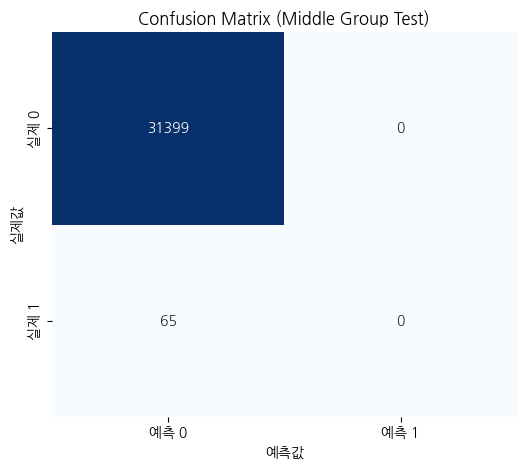

/tmp/ipython-input-2836903714.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


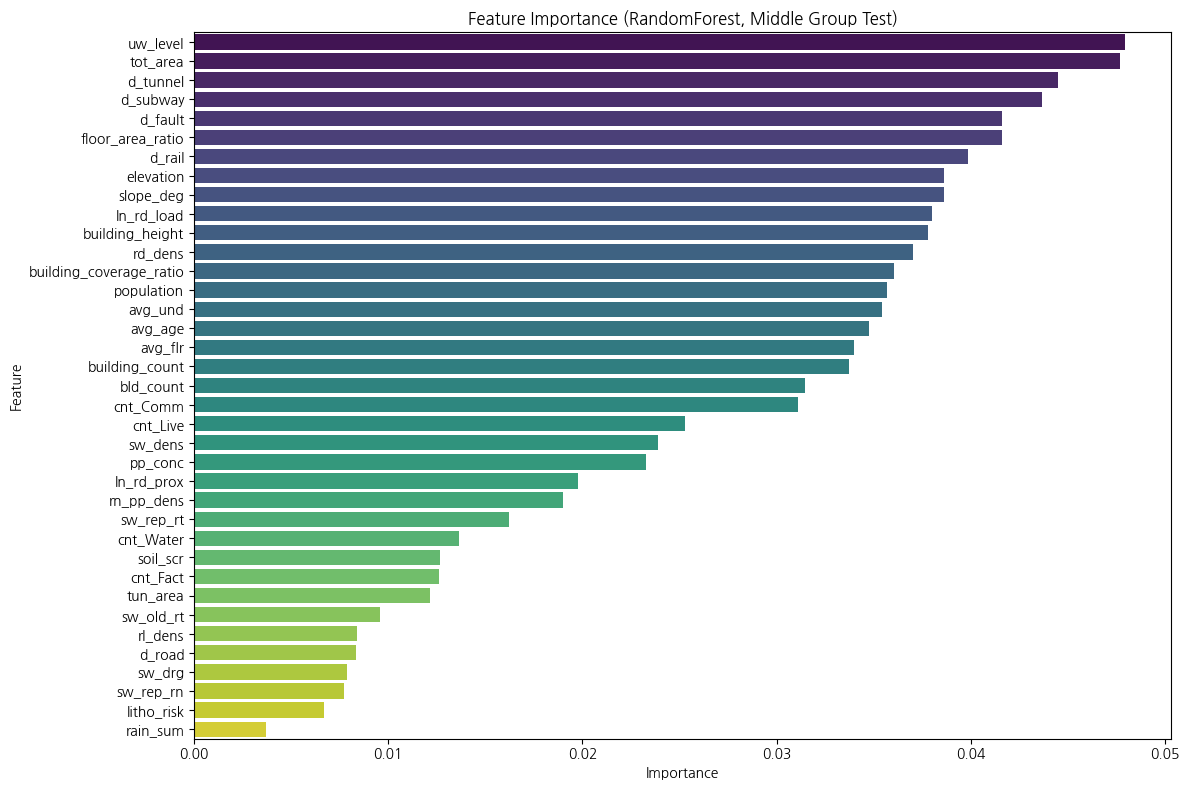

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ================================
# Middle Group 전체를 TEST로 사용
# ================================

# ================================
# 1) 기본 Feature 목록
# ================================
features = ['building_count', 'population',
       'building_coverage_ratio', 'building_height', 'floor_area_ratio',
       'litho_risk', 'd_fault', 'd_road', 'rd_dens',
       'ln_rd_load', 'ln_rd_prox', 'd_tunnel', 'tun_area', 'd_subway',
       'd_rail', 'rl_dens', 'elevation', 'slope_deg', 'bld_count', 'tot_area',
       'avg_flr', 'avg_age', 'avg_und', 'cnt_Comm', 'cnt_Fact'
       , 'cnt_Live', 'cnt_Water', 'soil_scr', 'uw_level'
       , 'rain_sum', 'sw_rep_rt', 'sw_rep_rn', 'sw_drg',
       'sw_old_rt', 'sw_dens', 'rn_pp_dens', 'pp_conc']

df = grid[features].apply(pd.to_numeric, errors="coerce")

# # ================================
# # 2) 상관관계 Heatmap (참고용)
# # ================================
# corr_matrix = df.corr()

# plt.figure(figsize=(18, 16))
# sns.heatmap(corr_matrix, annot=True,          # ★ 모든 칸에 수치 표시
#     fmt=".2f", cmap='coolwarm', linewidths=0.5)
# plt.title("📌 독립변수 간 상관관계 Heatmap", fontsize=20)
# plt.show()

# print("\n📌 상관계수 계산 완료")

# # ================================
# # 3) VIF 계산 → 삭제 대상 결정
# # ================================
# df_vif = df.dropna()
# vif_data = pd.DataFrame()
# vif_data["feature"] = df_vif.columns
# vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i)
#                    for i in range(df_vif.shape[1])]

# print("\n🟢 VIF 결과:")
# print(vif_data.sort_values("VIF", ascending=False))

# # 🔥 VIF 기준 설정 (일반적으로 10 이상 제거)
# vif_threshold = 10

# remove_list = vif_data[vif_data["VIF"] > vif_threshold]["feature"].tolist()
# print("\n🔴 VIF 기준 초과로 제거할 변수:", remove_list)

# # ================================
# # 4) 최종 features 결정
# # ================================
# cleaned_features = [f for f in features if f not in remove_list]

# print("\n📌 최종 사용될 변수 개수:", len(cleaned_features))
# print("📌 최종 Feature 목록:", cleaned_features)

# 시군별 발생건수 집계
city_event = grid.groupby("SGG_NM")["label"].sum().reset_index()
city_event.columns = ["city", "event_count"]

# # 3개군 미포함
# # 🔥 발생 0 도시 목록
# zero_cities = city_event[city_event["event_count"] == 0]["city"].tolist()
# print("발생 0 도시:", zero_cities)

# # 🔥 quantile 계산 및 Middle Group 산정을 위해 발생0 도시 제거
# city_event_nonzero = city_event[city_event["event_count"] > 0]

# q30 = city_event_nonzero["event_count"].quantile(0.30)
# q70 = city_event_nonzero["event_count"].quantile(0.70)

# middle_group = city_event_nonzero[
#     (city_event_nonzero["event_count"] > q30) &
#     (city_event_nonzero["event_count"] <= q70)
# ]

# 3개군 포함
# 30%, 70% quantile 계산
q30 = city_event["event_count"].quantile(0.30)
q70 = city_event["event_count"].quantile(0.70)

# Middle Group = 테스트 후보
middle_group = city_event[(city_event["event_count"] > q30) &
                          (city_event["event_count"] <= q70)]

print("🟢 Middle Group 테스트 도시들:")
print(middle_group)

# Middle Group 도시 리스트
test_cities = middle_group["city"].tolist()

#3개군 미포함
# Middle Group 제거 + 발생 0 도시 제거 → 훈련 인덱스
train_idx = (~grid["SGG_NM"].isin(test_cities)) & (~grid["SGG_NM"].isin(zero_cities))

# # 적용
# X_train = grid.loc[train_idx, cleaned_features].apply(pd.to_numeric, errors="coerce")
# y_train = grid.loc[train_idx, "label"].astype(int)

# # 테스트셋 (Middle Group만)
# test_idx = grid["SGG_NM"].isin(test_cities)
# X_test = grid.loc[test_idx, cleaned_features].apply(pd.to_numeric, errors="coerce")
# y_test = grid.loc[test_idx, "label"].astype(int)

# 적용
X_train = grid.loc[train_idx, features].apply(pd.to_numeric, errors="coerce")
y_train = grid.loc[train_idx, "label"].astype(int)

# 테스트셋 (Middle Group만)
test_idx = grid["SGG_NM"].isin(test_cities)
X_test = grid.loc[test_idx, features].apply(pd.to_numeric, errors="coerce")
y_test = grid.loc[test_idx, "label"].astype(int)

# 3개군 포함
# 테스트 행(중간 그룹 도시들)
test_idx = grid["SGG_NM"].isin(test_cities)

# 데이터 분리
# X_train = grid.loc[~test_idx, cleaned_features].apply(pd.to_numeric, errors="coerce")
# y_train = grid.loc[~test_idx, "label"].astype(int)

# X_test  = grid.loc[test_idx, cleaned_features].apply(pd.to_numeric, errors="coerce")
# y_test  = grid.loc[test_idx, "label"].astype(int)

# 데이터 분리
X_train = grid.loc[~test_idx, features].apply(pd.to_numeric, errors="coerce")
y_train = grid.loc[~test_idx, "label"].astype(int)

X_test  = grid.loc[test_idx, features].apply(pd.to_numeric, errors="coerce")
y_test  = grid.loc[test_idx, "label"].astype(int)

print("훈련 데이터 크기:", X_train.shape)
print("테스트 데이터 크기:", X_test.shape)

# ================================
# 🚀 RandomForest 모델 생성 + 학습
# ================================

rf = RandomForestClassifier(
    n_estimators=500,       # 트리 수 증가 → 성능 안정
    max_depth=None,         # 제한 없음 (BRF와 달리 RF는 깊게 가도 괜찮음)
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ================================
# 예측 + 성능 평가
# ================================

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("\n====================== Middle Group RandomForest 결과 ======================")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

# ================================
# Confusion Matrix 출력 + 시각화
# ================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['실제 0', '실제 1'],
    columns=['예측 0', '예측 1']
)

print("\n혼동행렬:")
print(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix (Middle Group Test)")
plt.xlabel("예측값")
plt.ylabel("실제값")
plt.show()

# ================================
# Feature Importance 시각화
# ================================

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # 큰 순서대로 정렬

# plt.figure(figsize=(12, 8))
# sns.barplot(
#     x=importances[indices],
#     y=np.array(cleaned_features)[indices],
#     palette="viridis"
# )

plt.figure(figsize=(12, 8))
sns.barplot(
    x=importances[indices],
    y=np.array(features)[indices],
    palette="viridis"
)

plt.title("Feature Importance (RandomForest, Middle Group Test)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

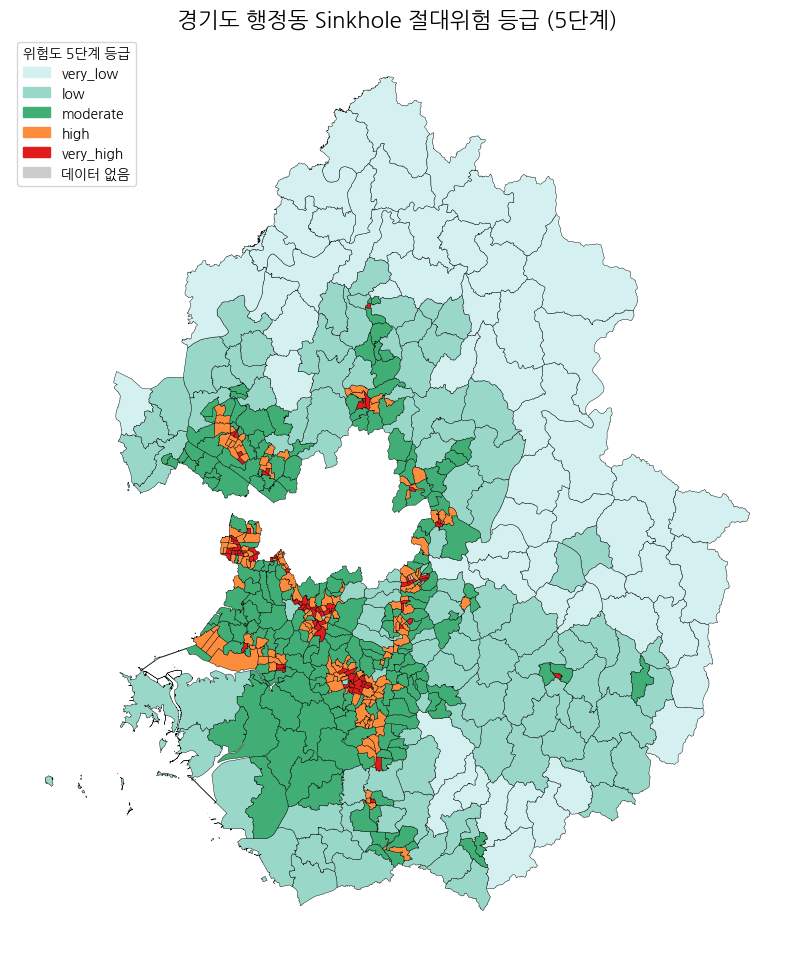

In [ ]:
#시각화1---------------

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

dong_gdf = gpd.read_file("/content/경기도_행정동_5181.gpkg")
# dong_gdf = gpd.read_file("/content/경기도행정동_하천제거_5181.gpkg")

features

dong_gdf = dong_gdf.rename(columns={"읍면동명칭": "DONG"})

X_all = grid[features].apply(pd.to_numeric, errors='coerce')
grid["risk"] = model.predict_proba(X_all)[:, 1]

bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["very_low", "low", "moderate", "high", "very_high"]

grid["risk_level"] = pd.cut(
    grid["risk"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

dong_stats = (
    grid
    .groupby("DONG")
    .agg(
        n_grid=("risk", "size"),
        mean_risk=("risk", "mean"),
        max_risk=("risk", "max"),
        very_low_ratio=("risk_level", lambda x: (x=="very_low").mean()),
        low_ratio=("risk_level", lambda x: (x=="low").mean()),
        moderate_ratio=("risk_level", lambda x: (x=="moderate").mean()),
        high_ratio=("risk_level", lambda x: (x=="high").mean()),
        very_high_ratio=("risk_level", lambda x: (x=="very_high").mean())
    )
    .reset_index()
)

dong_stats["dong_risk_level"] = pd.cut(
    dong_stats["mean_risk"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

dong_map = dong_gdf.merge(dong_stats, on="DONG", how="left")

color_map = {
    "very_low":  "#d4f0f0",
    "low":       "#99d8c9",
    "moderate":  "#41ae76",
    "high":      "#fd8d3c",
    "very_high": "#e31a1c"
}

# 1) 위험등급 → 색상 매핑 + object 타입으로 변환
dong_map["color"] = dong_map["dong_risk_level"].map(color_map).astype("object")

# 2) NaN을 회색으로 채우기
dong_map["color"] = dong_map["color"].fillna("#cccccc")

fig, ax = plt.subplots(1, 1, figsize=(10, 12))

dong_map.plot(
    color=dong_map["color"],
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

patches = [
    mpatches.Patch(color=color_map[k], label=k)
    for k in color_map
]
patches.append(mpatches.Patch(color="#cccccc", label="데이터 없음"))

ax.legend(handles=patches, title="위험도 5단계 등급", loc="upper left")
ax.set_title("경기도 행정동 Sinkhole 절대위험 등급 (5단계)", fontsize=16)
ax.set_axis_off()

plt.show()


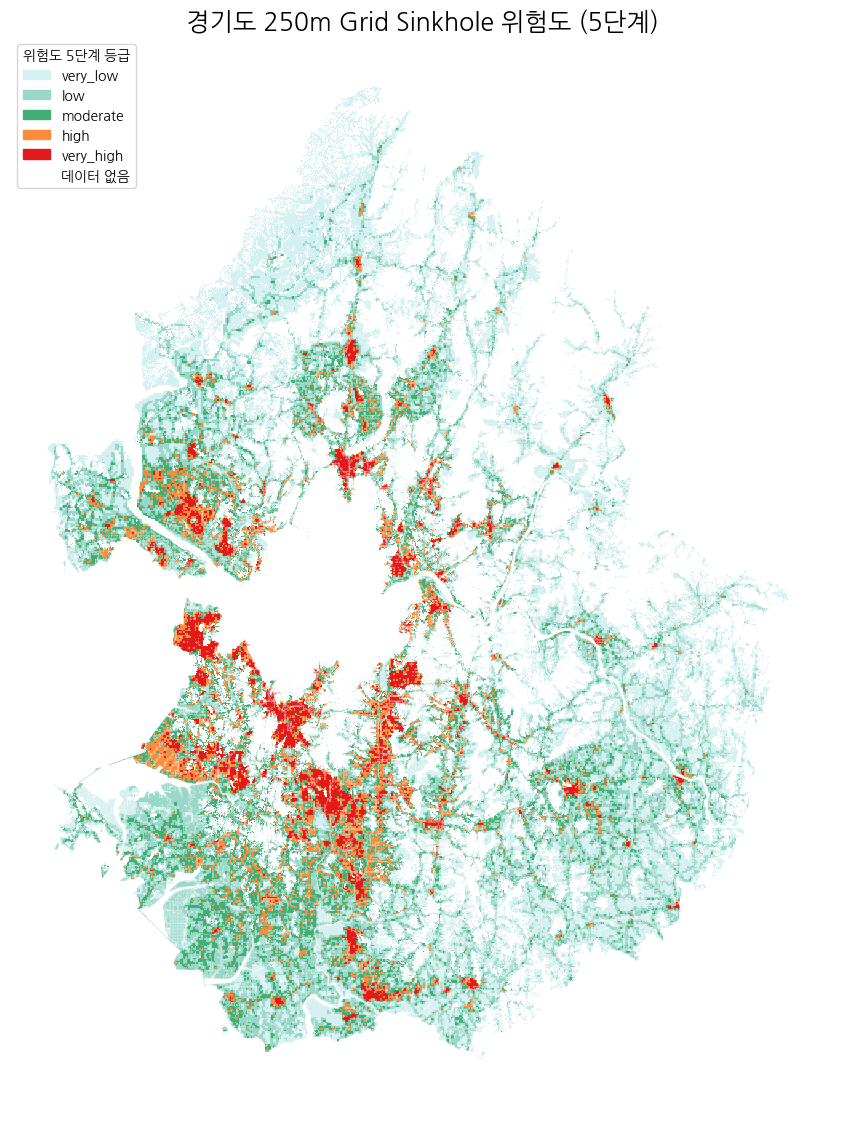

In [ ]:
#시각화2---------------

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

final = gpd.read_file("/content/final_df.gpkg")

features = ['building_count', 'population',
       'building_coverage_ratio', 'building_height', 'floor_area_ratio',
       'litho_risk', 'd_fault', 'd_road', 'rd_dens',
       'ln_rd_load', 'ln_rd_prox', 'd_tunnel', 'tun_area', 'd_subway',
       'd_rail', 'rl_dens', 'elevation', 'slope_deg', 'bld_count', 'tot_area',
       'avg_flr', 'avg_age', 'avg_und', 'cnt_Comm', 'cnt_Fact'
       , 'cnt_Live', 'cnt_Water', 'soil_scr', 'uw_level'
       , 'rain_sum', 'sw_rep_rt', 'sw_rep_rn', 'sw_drg',
       'sw_old_rt', 'sw_dens', 'rn_pp_dens', 'pp_conc']

keep_cols = ["id", "SGG_NM", "DONG", "label"]   # 반드시 유지해야 하는 컬럼


# B의 feature 리스트 기준으로 A에 동일한 열 만들기
for col in features:
    if col not in final.columns:
        final[col] = None   # 또는 0으로 채울 수도 있음 (데이터 의미에 따라)

final = final[keep_cols + features + ["geometry"]] # geometry 포함하여 정렬

X = final[features].apply(pd.to_numeric, errors='coerce')
final["risk"] = model.predict_proba(X)[:, 1]

bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["very_low", "low", "moderate", "high", "very_high"]

final["risk_level"] = pd.cut(
    final["risk"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

colors = {
    "very_low":  "#d4f0f0",
    "low":       "#99d8c9",
    "moderate":  "#41ae76",
    "high":      "#fd8d3c",
    "very_high": "#e31a1c"
}

# 2) NaN을 회색으로 채우기
dong_map["color"] = dong_map["color"].fillna("#ffffff")

patches = [
    mpatches.Patch(color=color_map[k], label=k)
    for k in color_map
]
patches.append(mpatches.Patch(color="#ffffff", label="데이터 없음"))

final["color"] = final["risk_level"].map(colors)

fig, ax = plt.subplots(figsize=(12, 14))
final.plot(color=final["color"], ax=ax, linewidth=0)
ax.legend(handles=patches, title="위험도 5단계 등급", loc="upper left")
ax.set_title("경기도 250m Grid Sinkhole 위험도 (5단계)", fontsize=18)
ax.set_axis_off()
plt.show()


In [ ]:
import pickle

# 학습된 모델이 model 변수에 있다고 가정
save_obj = {
    "model": model,
    "features": features,
    "threshold": 0.5
}

with open("brf_sinkhole_bundle.pkl", "wb") as f:
    pickle.dump(save_obj, f)


In [ ]:
import pickle

with open("brf_sinkhole_bundle.pkl", "rb") as f:
    bundle = pickle.load(f)

model = bundle["model"]
features = bundle["features"]
threshold = bundle["threshold"]


In [ ]:
# 확률 예측
X_all = grid[features]

grid["risk"] = model.predict_proba(X_all)[:, 1]
grid["pred"] = (grid["risk"] >= threshold).astype(int)


In [ ]:
grid_4326 = final.to_crs(4326)

In [ ]:
final

,id,SGG_NM,DONG,label,building_count,population,building_coverage_ratio,building_height,floor_area_ratio,litho_risk,...,sw_rep_rn,sw_drg,sw_old_rt,sw_dens,rn_pp_dens,pp_conc,geometry,risk,risk_level,color
0,119917,군포시,오금동,0,0,1194.00,9.38,37.83,129.37,1.0,...,0.000000,0.017772,0.000000,20326.286765,1629.560440,87.877911,"MULTIPOLYGON (((193289.203 428207.758, 193539....",0.745598,high,#fd8d3c
1,119918,군포시,오금동,0,0,1823.00,13.54,33.14,115.17,1.0,...,0.000000,0.017772,0.000000,20326.286765,1629.560440,87.877911,"MULTIPOLYGON (((193289.203 427957.758, 193539....",0.809607,very_high,#e31a1c
2,119919,군포시,오금동,0,0,669.00,32.73,24.22,140.01,1.0,...,0.000000,0.017772,0.000000,18001.903052,3764.915888,93.416216,"MULTIPOLYGON (((193539.203 427707.758, 193539....",0.771037,high,#fd8d3c
3,119920,군포시,오금동,0,0,1716.00,16.67,49.84,72.00,1.0,...,0.000000,0.017772,0.000000,18001.903052,3764.915888,93.416216,"MULTIPOLYGON (((193420 427457.758, 193420 4274...",0.733395,high,#fd8d3c
4,119921,군포시,오금동,0,0,1716.00,16.67,49.84,72.00,1.0,...,0.000000,0.017772,0.000000,18001.903052,3764.915888,93.416216,"MULTIPOLYGON (((193360 427205, 193355 427205, ...",0.441947,moderate,#41ae76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132537,114191,파주시,광탄면,0,0,0,0,0,0,1.0,...,0.000065,0.075563,66.666667,26900.192000,241.581998,29.128149,"MULTIPOLYGON (((191289.203 473610, 191285 4736...",0.074406,very_low,#d4f0f0
132538,114192,파주시,광탄면,0,0,0,0,0,0,1.0,...,0.000065,0.075563,66.666667,26900.192000,241.581998,29.128149,"MULTIPOLYGON (((191289.203 473457.758, 191289....",0.017443,very_low,#d4f0f0
132539,114193,파주시,광탄면,0,0,0,0,0,0,1.0,...,0.000065,0.075563,66.666667,26900.192000,241.581998,29.128149,"MULTIPOLYGON (((191235 473207.758, 191235 4732...",0.014895,very_low,#d4f0f0
132540,114194,파주시,광탄면,0,0,0,0,0,0,1.0,...,0.000065,0.075563,66.666667,26900.192000,241.581998,29.128149,"MULTIPOLYGON (((191165 472957.758, 191165 4729...",0.010467,very_low,#d4f0f0


In [ ]:
vis = final[["id", "SGG_NM", "DONG", "risk", "risk_level", "geometry","color"]]
vis.to_file("경기도_250m_risk_5단계.gpkg", driver="GPKG")

In [ ]:
# import folium
# import numpy as np

# # 1) 4326 좌표계로 변환
# grid_4326 = final.to_crs(4326)

# # 2) geometry 단순화 (데이터량 큰 경우 필수)
# grid_s = grid_4326.copy()
# grid_s["geometry"] = grid_s.geometry.simplify(8, preserve_topology=True)

# # 3) 5단계 컬러 매핑
# risk_colors = {
#     "very_low": "#ccece6",
#     "low": "#99d8c9",
#     "moderate": "#41ae76",
#     "high": "#238b45",
#     "very_high": "#00441b",
#     "no_data": "#ffffff"
# }

# def get_color(level):
#     if level in risk_colors:
#         return risk_colors[level]
#     return "#ffffff"

# # 4) 지도 중심
# center = [grid_s.geometry.centroid.y.mean(), grid_s.geometry.centroid.x.mean()]

# # 5) 구글맵 스타일 (Stamen Terrain, Toner 등도 가능)
# m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

# # 6) 대량 polygon을 chunk로 나눠 folium 렌더링 속도 개선
# chunks = np.array_split(grid_s, 6)

# for i, chunk in enumerate(chunks):
#     folium.GeoJson(
#         chunk,
#         name=f"grid_part_{i}",
#         style_function=lambda feature: {
#             "fillColor": get_color(feature["properties"]["risk_level"]),
#             "color": "#00000000",   # 투명선
#             "weight": 0,
#             "fillOpacity": 0.7,
#         },
#         tooltip=folium.GeoJsonTooltip(
#             fields=["risk", "risk_level"],
#             aliases=["Risk:", "Level:"],
#             localize=True
#         ),
#         popup=folium.GeoJsonPopup(
#             fields=["risk", "risk_level", "DONG", "SGG_NM"],
#             aliases=["Risk", "Risk Level", "Dong", "City/County"],
#             localize=True,
#         )
#     ).add_to(m)

# folium.LayerControl().add_to(m)

# # m = folium.Map(
# #     location=center,
# #     zoom_start=11,
# #     tiles="https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png",
# #     attr="Google"
# # )

# m


In [ ]:
!pip install dbfread
from dbfread import DBF
import pandas as pd

encodings = ['cp949', 'euc-kr', 'utf-8', 'latin1', 'cp437', 'iso-8859-1', 'ms949']

for enc in encodings:
    try:
        print(f"=== Trying encoding: {enc} ===")
        table = DBF('Geology_250K_Litho.dbf', encoding=enc)
        df = pd.DataFrame(iter(table))
        print(df.head(3))
        print("\n\n")
    except Exception as e:
        print(f"{enc} failed: {e}\n")


=== Trying encoding: cp949 ===
cp949 failed: 'cp949' codec can't decode byte 0xec in position 0: illegal multibyte sequence

=== Trying encoding: euc-kr ===
euc-kr failed: 'euc_kr' codec can't decode byte 0xec in position 0: illegal multibyte sequence

=== Trying encoding: utf-8 ===
     fid   gid  ageno      age mapidx mapname ref comt str_age  \
0  10978  2277    400  선캄브리아시대             안동                    
1  11121  2438    400  선캄브리아시대             안동                    
2  11124  2447    400  선캄브리아시대             안동                    

        lithoname symnum lithoidx refrock    shape_area     shape_len  
0  소백산편마암복합체 원남층군              ls     석회암  6.391513e+05   5409.738964  
1  소백산편마암복합체 원남층군              ls     석회암  6.313595e+06  17112.189539  
2  소백산편마암복합체 원남층군              ls     석회암  1.902487e+06   7180.766915  



=== Trying encoding: latin1 ===
     fid   gid  ageno                    age mapidx mapname ref comt str_age  \
0  10978  2277    400  ì ìºë¸ë¦¬ììë    

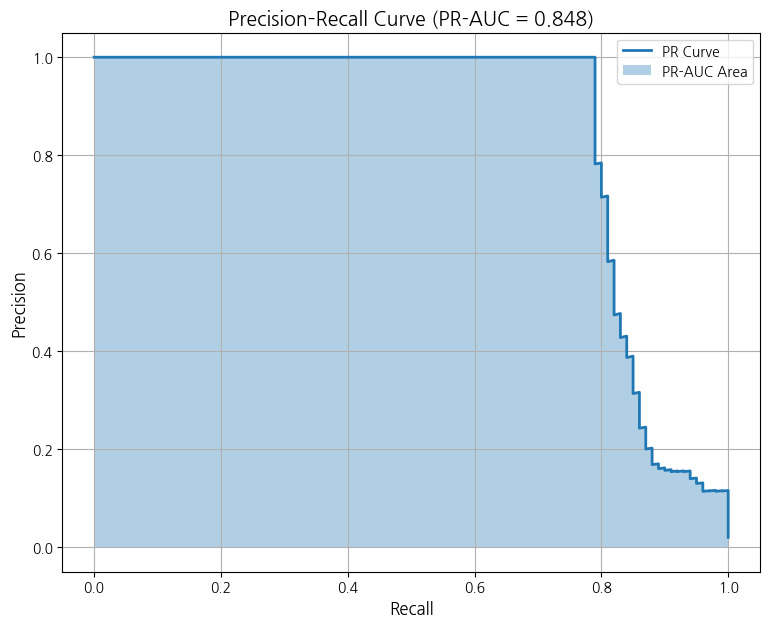

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# =========================
# 1. 가상 불균형 데이터
# =========================
np.random.seed(42)

n = 5000
y_true = np.zeros(n)
y_true[:100] = 1   # 양성 2%
np.random.shuffle(y_true)

y_score = (
    y_true * np.random.uniform(0.5, 1.0, n) +
    (1 - y_true) * np.random.uniform(0.0, 0.6, n)
)

# =========================
# 2. PR curve 계산
# =========================
precision, recall, _ = precision_recall_curve(y_true, y_score)
pr_auc = average_precision_score(y_true, y_score)

# =========================
# 3. 시각화 (PR-AUC 영역 색칠)
# =========================
plt.figure(figsize=(9, 7))

# PR curve
plt.plot(recall, precision, linewidth=2, label="PR Curve")

# PR-AUC 면적
plt.fill_between(
    recall,
    precision,
    alpha=0.35,
    label="PR-AUC Area"
)

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title(f"Precision–Recall Curve (PR-AUC = {pr_auc:.3f})", fontsize=14)
plt.legend()
plt.grid(True)

plt.show()
